In [1]:
!pip install xgboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00


In [2]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, jaccard_score, roc_auc_score, precision_score, recall_score, f1_score
from typing import List, Tuple, cast
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
)

from typing import List, Tuple, cast

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from catboost import CatBoostClassifier, Pool

## **First Try different models**

In [3]:
ROOT = Path().resolve()
DATA = ROOT.parent  / "content"
#CSV_EXPORTS = ROOT / "csv_exports"  # Ruta a los CSV exportados desde preprocessing

# Cargar dataframe para las partes anteriores del notebook (celdas 2-5, 7-8)
# Nota: df_exp_50_variable_selection.csv no existe, así que cargamos df_exp_50.csv
# El código nuevo en la celda 6 carga directamente df_exp_50.csv con timestamp para el análisis temporal
df = pd.read_csv("df_exp_50.csv")

## **Temporal Split Model**
- Temporal split
- Feature Selection (only PCA variables)
- Test all datasets with different proportions

Nota sobre el dataset (50/50)

Usamos el dataframe balanceado `df_exp_50.csv` (50% fraud / 50% no fraud) exportado desde `notebooks/csv_exports/`. Ese archivo ya incluye `timestamp` del merge en `preprocessing.ipynb`, así que no rehacemos merges ni derivamos de nuevo las features temporales base; solo convertimos `timestamp` a datetime y extraemos la fecha para el split temporal por día.


Dataframe completo cargado: (31920, 77)
Columnas disponibles: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']...
✓ Columna 'timestamp' encontrada

=== Análisis de días únicos ===
Número de días únicos: 1

Distribución de transacciones por día:
timestamp
2023-01-01    31919
Name: count, dtype: int64

=== Balance de clases por día ===

Fecha: 2023-01-01
  Total transacciones: 31919
  Clase 0 (No fraude): 31647
  Clase 1 (Fraude): 272
  % Fraude: 0.85%

⚠️ ADVERTENCIA: Solo hay un día de datos. No se puede hacer split temporal.

=== Selección de variables PCA ===
Variables PCA disponibles: 28 de 28
Variables: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

Shape del dataframe PCA: (31920, 30)

=== Análisis de correlaciones entre variables PCA ===

Pares de variables con correlación >= 0.8: 0

=== Correlaciones con el target (Class) ===


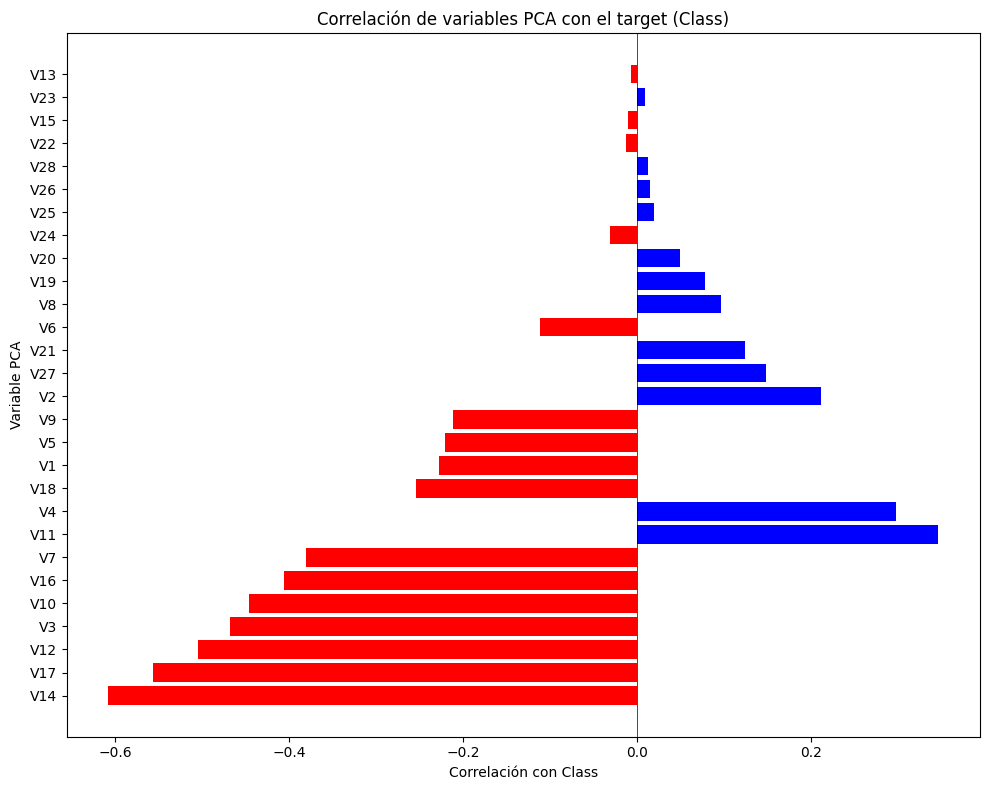


=== Eliminación de variables correlacionadas ===

Variables PCA iniciales: 28
Variables eliminadas por correlación: 0
Variables PCA finales: 28
Variables finales: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

=== Split temporal por día ===
No se pudo hacer split temporal. Usando split aleatorio como fallback.

=== Train set sin SMOTE (split aleatorio) ===
Class
0    25318
1      218
Name: count, dtype: int64

=== Entrenamiento con LightGBM (solo variables PCA filtradas) ===
Entrenando modelo...

===== LightGBM (PCA variables, split temporal) =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6330
           1       1.00      0.98      0.99        54

    accuracy                           1.00      6384
   macro avg       1.00      0.99      1.00      6384
weighted avg       1.00      1

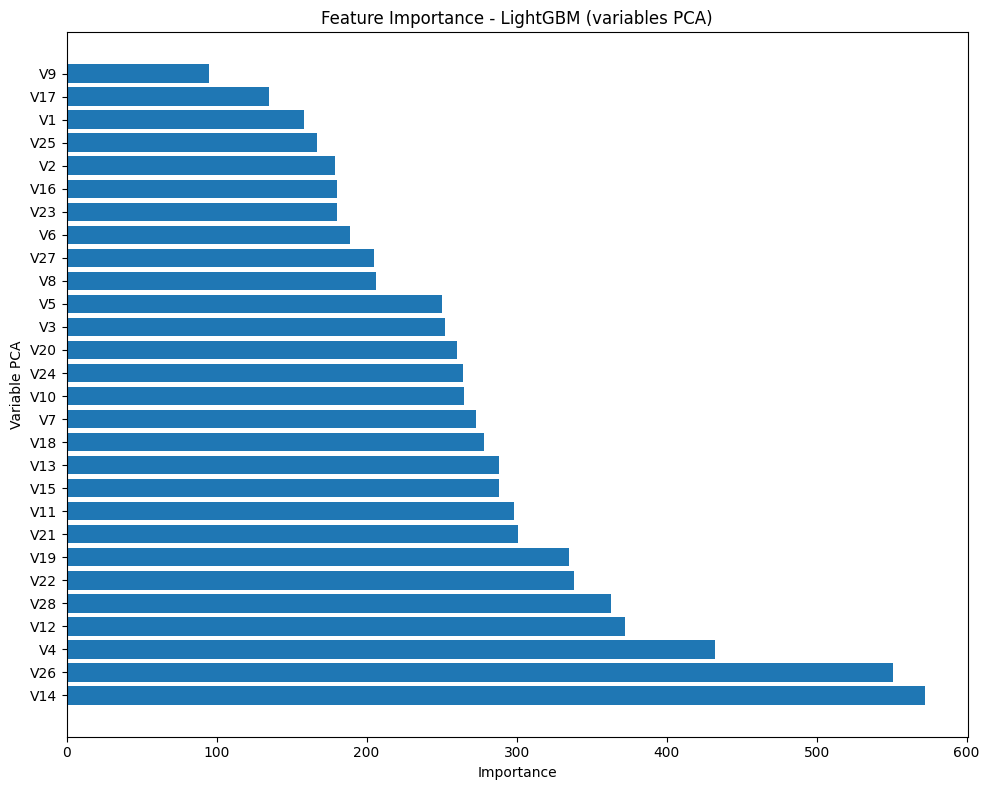

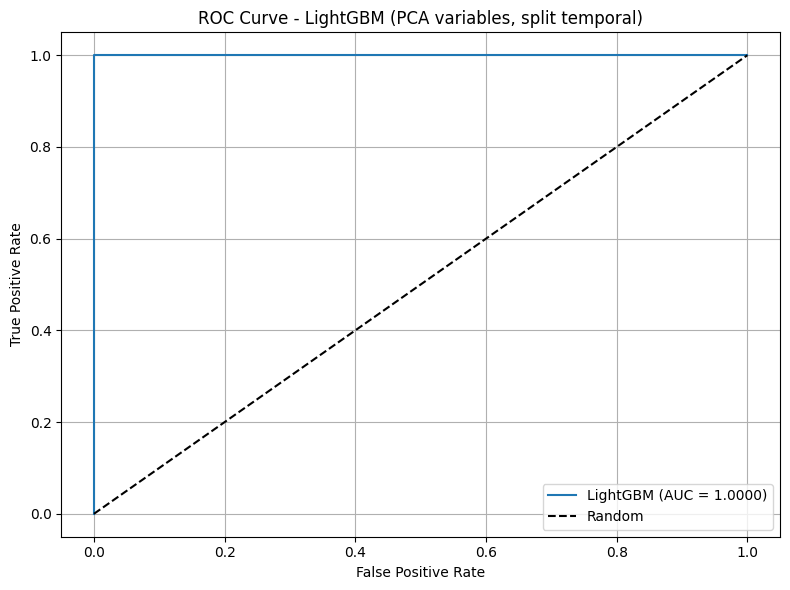


=== Resumen de la implementación ===
✓ Variables PCA iniciales: 28
✓ Variables eliminadas por correlación: 0
✓ Variables PCA finales usadas: 28
✓ Modelo: LightGBM
✓ ROC AUC: 1.0000


In [ ]:
# ==============================================================================
# NUEVA SECCIÓN: Feature Selection y Split Temporal
# ==============================================================================
"""
Implementación de las mejoras acordadas:
1. Split temporal: train y test cada uno con un día completo
2. Usar solo variables PCA (V1-V28)
3. Eliminar variables correlacionadas
4. Analizar correlaciones con el target
5. Enfocarse en LightGBM (dado que CatBoost parece poco fiable)
"""


# Cargar el dataframe completo desde preprocessing que ya tiene timestamp
#CSV_EXPORTS = Path().resolve() / "csv_exports"
#df_full = pd.read_csv(CSV_EXPORTS / "df_exp_50.csv")
df_full = pd.read_csv("df_exp_50.csv")
print(f"Dataframe completo cargado: {df_full.shape}")
print(f"Columnas disponibles: {list(df_full.columns)[:10]}...")  # Mostrar primeras 10

# Verificar si tiene timestamp (debería tenerlo según preprocessing.ipynb)
if 'timestamp' in df_full.columns:
    print("✓ Columna 'timestamp' encontrada")
    df_work = df_full.copy()
else:
    raise ValueError("df_exp_50.csv no contiene la columna 'timestamp'. Verifica preprocessing/export.")

# =============================
# 1. Análisis de datos temporales
# =============================

ts_series = df_work['timestamp'] if 'timestamp' in df_work.columns else None

if ts_series is not None and bool(ts_series.notna().any()):
    # Convertir timestamp a datetime si es necesario
    ts_series = pd.to_datetime(ts_series, errors='coerce')
    df_work['timestamp'] = ts_series

    # Extraer la fecha (día)
    date_series = ts_series.dt.date
    df_work['date'] = date_series

    # Analizar días únicos
    unique_dates = pd.Series(date_series).value_counts().sort_index()
    print("\n=== Análisis de días únicos ===")
    print(f"Número de días únicos: {pd.Series(date_series).nunique()}")
    print("\nDistribución de transacciones por día:")
    print(unique_dates.head(10))  # Mostrar primeros 10 días

    # Verificar balance de clases por día
    print("\n=== Balance de clases por día ===")
    for date in sorted(pd.Series(date_series).dropna().unique())[:5]:  # Mostrar primeros 5 días
        day_mask = df_work['date'] == date
        day_data = df_work.loc[day_mask]
        class_counts = day_data['Class'].value_counts()
        total_day = len(day_data)
        fraud_count = float(class_counts.get(1, 0))
        print(f"\nFecha: {date}")
        print(f"  Total transacciones: {total_day}")
        print(f"  Clase 0 (No fraude): {class_counts.get(0, 0)}")
        print(f"  Clase 1 (Fraude): {int(fraud_count)}")
        if total_day > 0:
            print(f"  % Fraude: {fraud_count / float(total_day) * 100:.2f}%")

    # Seleccionar días para train y test
    sorted_dates = sorted(pd.Series(date_series).dropna().unique())
    if len(sorted_dates) >= 2:
        train_date = sorted_dates[0]  # Primer día para train
        test_date = sorted_dates[1]   # Segundo día para test
        print(f"\n=== Días seleccionados ===")
        print(f"Train date: {train_date}")
        print(f"Test date: {test_date}")
    else:
        print("\nADVERTENCIA: Solo hay un día de datos. No se puede hacer split temporal.")
        train_date = sorted_dates[0] if len(sorted_dates) > 0 else None
        test_date = None
else:
    print("ADVERTENCIA: No se encontró la columna 'timestamp' válida en el dataframe.")
    train_date = None
    test_date = None

# =============================
# 2. Selección de variables PCA (V1-V28)
# =============================

print("\n=== Selección de variables PCA ===")

# Verificar qué variables V1-V28 están disponibles
pca_vars = [f'V{i}' for i in range(1, 29)]
available_pca_vars = [var for var in pca_vars if var in df_work.columns]
subset_vars = list(available_pca_vars)

print(f"Variables PCA disponibles: {len(available_pca_vars)} de 28")
print(f"Variables: {available_pca_vars}")

if len(available_pca_vars) == 0:
    raise ValueError("No se encontraron variables PCA (V1-V28) en el dataframe")

# Crear dataframe solo con variables PCA, target y date (si existe)
cols_to_include = subset_vars + ['Class']
if 'date' in df_work.columns:
    cols_to_include.append('date')

df_pca = df_work[cols_to_include].copy()

# Verificar valores faltantes
pca_only: pd.DataFrame = df_pca.loc[:, subset_vars]
missing_pca = pca_only.isnull().sum()
if missing_pca.sum() > 0:
    print(f"\n Valores faltantes en variables PCA:")
    print(missing_pca[missing_pca > 0])
    # Eliminar filas con valores faltantes
    df_pca = df_pca.dropna(subset=subset_vars)
    pca_only = df_pca.loc[:, subset_vars]
    print(f"Filas después de eliminar NaN: {len(df_pca)}")

print(f"\nShape del dataframe PCA: {df_pca.shape}")

# =============================
# 3. Análisis de correlaciones entre variables PCA
# =============================

print("\n=== Análisis de correlaciones entre variables PCA ===")

# Calcular matriz de correlación
corr_matrix: pd.DataFrame = pca_only.corr().abs()

# Identificar pares de variables altamente correlacionadas
threshold = 0.8  # Threshold para considerar alta correlación
high_corr_pairs: List[Tuple[str, str, float]] = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] >= threshold:  # type: ignore
            high_corr_pairs.append((
                str(corr_matrix.columns[i]),
                str(corr_matrix.columns[j]),
                float(corr_matrix.iloc[i, j])
            ))

print(f"\nPares de variables con correlación >= {threshold}: {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nPares altamente correlacionados:")
    for var1, var2, corr_val in high_corr_pairs[:10]:  # Mostrar primeros 10
        print(f"  {var1} <-> {var2}: {corr_val:.4f}")

# =============================
# 4. Correlaciones con el target
# =============================

print("\n=== Correlaciones con el target (Class) ===")

# Calcular correlación de cada variable PCA con Class
corr_with_target: pd.DataFrame = df_pca.loc[:, subset_vars + ['Class']].corr()
target_corr = corr_with_target['Class'].drop('Class')
target_corr_abs = target_corr.abs().sort_values(ascending=False)

print("\nCorrelaciones con Class (ordenadas por magnitud absoluta):")
print(target_corr_abs.to_frame('Correlation_with_Class'))

# Visualizar correlaciones con el target
plt.figure(figsize=(10, 8))
target_corr_sorted = target_corr.reindex(target_corr_abs.index)
target_corr_sorted_values: np.ndarray = target_corr_sorted.to_numpy(dtype=float)

colors = ['red' if x < 0 else 'blue' for x in target_corr_sorted_values]

yticks_positions = np.arange(len(target_corr_sorted_values))
yticks_labels: List[str] = [str(idx) for idx in target_corr_sorted.index]

plt.barh(yticks_positions, target_corr_sorted_values, color=colors)
plt.yticks(yticks_positions, yticks_labels)
plt.xlabel('Correlación con Class')
plt.ylabel('Variable PCA')
plt.title('Correlación de variables PCA con el target (Class)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# =============================
# 5. Eliminar variables correlacionadas
# =============================
print("\n=== Eliminación de variables correlacionadas ===")

vars_to_remove: set[str] = set()
vars_considered: set[str] = set(available_pca_vars)

for var1, var2, corr_val in high_corr_pairs:
    # Si alguna de las dos ya está eliminada, saltamos este par
    if var1 in vars_to_remove or var2 in vars_to_remove:
        continue

    corr1_with_target = abs(float(target_corr[var1]))
    corr2_with_target = abs(float(target_corr[var2]))

    if corr1_with_target >= corr2_with_target:
        # Nos quedamos con var1, eliminamos var2
        vars_to_remove.add(var2)
        print(
            f"  Eliminando {var2} (corr con target: {corr2_with_target:.4f}) "
            f"vs {var1} (corr con target: {corr1_with_target:.4f})"
        )
    else:
        # Nos quedamos con var2, eliminamos var1
        vars_to_remove.add(var1)
        print(
            f"  Eliminando {var1} (corr con target: {corr1_with_target:.4f}) "
            f"vs {var2} (corr con target: {corr2_with_target:.4f})"
        )

final_pca_vars = [var for var in available_pca_vars if var not in vars_to_remove]

print(f"\nVariables PCA iniciales: {len(available_pca_vars)}")
print(f"Variables eliminadas por correlación: {len(vars_to_remove)}")
print(f"Variables PCA finales: {len(final_pca_vars)}")
print(f"Variables finales: {final_pca_vars}")

# Actualizar dataframe con solo las variables seleccionadas
cols_final = final_pca_vars + ['Class']
if 'date' in df_pca.columns:
    cols_final.append('date')
df_pca_final = df_pca[cols_final].copy()

# =============================
# 6. Split temporal por día
# =============================

print("\n=== Split temporal por día ===")

if train_date is not None and test_date is not None and 'date' in df_pca_final.columns:
    # Split por día
    train_mask = df_pca_final['date'] == train_date
    test_mask = df_pca_final['date'] == test_date

    X_train_temp = df_pca_final.loc[train_mask, final_pca_vars].copy()
    y_train_temp = df_pca_final.loc[train_mask, 'Class'].copy()

    X_test_temp = df_pca_final.loc[test_mask, final_pca_vars].copy()
    y_test_temp = df_pca_final.loc[test_mask, 'Class'].copy()

    print(f"Train set - Día: {train_date}")
    print(f"  Shape: {X_train_temp.shape}")
    print(f"  Clase 0: {(y_train_temp == 0).sum()}")
    print(f"  Clase 1: {(y_train_temp == 1).sum()}")
    if len(y_train_temp) > 0:  # type: ignore
        print(f"  % Fraude: {(y_train_temp == 1).sum() / len(y_train_temp) * 100:.2f}%")  # type: ignore

    print(f"\nTest set - Día: {test_date}")
    print(f"  Shape: {X_test_temp.shape}")
    print(f"  Clase 0: {(y_test_temp == 0).sum()}")
    print(f"  Clase 1: {(y_test_temp == 1).sum()}")
    if len(y_test_temp) > 0:  # type: ignore
        print(f"  % Fraude: {(y_test_temp == 1).sum() / len(y_test_temp) * 100:.2f}%")  # type: ignore

    # SIN SMOTE: usamos directamente el train original
    print("\n=== Train set sin SMOTE ===")
    print(y_train_temp.value_counts())
    X_train_res_temp = X_train_temp
    y_train_res_temp = y_train_temp

else:
    print("No se pudo hacer split temporal. Usando split aleatorio como fallback.")
    X_all = df_pca_final.loc[:, final_pca_vars].copy()
    y_all = df_pca_final.loc[:, 'Class'].copy()

    split_result = train_test_split(
        X_all,
        y_all,
        test_size=0.2,
        random_state=42,
        stratify=y_all,
    )
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = cast(
        Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series],
        split_result,
    )

    # SIN SMOTE también aquí
    print("\n=== Train set sin SMOTE (split aleatorio) ===")
    print(y_train_temp.value_counts())
    X_train_res_temp = X_train_temp
    y_train_res_temp = y_train_temp

# =============================
# 7. Entrenamiento con LightGBM
# =============================

print("\n=== Entrenamiento con LightGBM (solo variables PCA filtradas) ===")

# Entrenar LightGBM
lgb_model_pca = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

print("Entrenando modelo...")
lgb_model_pca.fit(X_train_res_temp, y_train_res_temp)

# Predicciones
y_pred_lgb_pca = lgb_model_pca.predict(X_test_temp)
y_proba_lgb_pca = lgb_model_pca.predict_proba(X_test_temp)[:, 1]  # type: ignore

# Métricas
print("\n===== LightGBM (PCA variables, split temporal) =====")
print(classification_report(y_test_temp, y_pred_lgb_pca))  # type: ignore
print(f"ROC AUC: {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test_temp, y_pred_lgb_pca)  # type: ignore
print("\nMatriz de confusión:")
print(cm)

# Feature importance
feature_importance_pca = pd.Series(
    lgb_model_pca.feature_importances_,
    index=final_pca_vars
).sort_values(ascending=False)

print("\n=== Feature Importance (Top 10) ===")
print(feature_importance_pca.head(10))

# Visualizar feature importance
plt.figure(figsize=(10, 8))
fi_values: np.ndarray = feature_importance_pca.to_numpy(dtype=float)
fi_positions = np.arange(len(fi_values))
fi_labels: List[str] = [str(idx) for idx in feature_importance_pca.index]

plt.barh(fi_positions, fi_values)
plt.yticks(fi_positions, fi_labels)
plt.xlabel('Importance')
plt.ylabel('Variable PCA')
plt.title('Feature Importance - LightGBM (variables PCA)')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_temp, y_proba_lgb_pca)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM (PCA variables, split temporal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== Resumen de la implementación ===")
print(f"✓ Variables PCA iniciales: {len(available_pca_vars)}")
print(f"✓ Variables eliminadas por correlación: {len(vars_to_remove)}")
print(f"✓ Variables PCA finales usadas: {len(final_pca_vars)}")
if train_date is not None and test_date is not None:
    print(f"✓ Train date: {train_date}")
    print(f"✓ Test date: {test_date}")
print(f"✓ Modelo: LightGBM")
print(f"✓ ROC AUC: {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f}")


In [ ]:
# ============================================================================
# Análisis detallado con métricas apropiadas para desbalance extremo
# Evaluación de TODOS los datasets sintéticos (requisito del proyecto)
# ============================================================================
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
)
import numpy as np

def eval_desbalanceado_detallado(df_in: pd.DataFrame, name: str) -> dict:
    """Evalúa con métricas apropiadas para datasets extremadamente desbalanceados.
    - Split temporal día 1 / día 2
    - Usa solo variables PCA (V1-V28)
    - Elimina variables PCA muy correlacionadas entre sí
      quedándose con la más correlacionada con el target.
    Retorna diccionario con métricas clave para comparación.
    """
    print(f"\n{'='*60}")
    print(f"Análisis detallado: {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No hay timestamp; se omite.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Selección inicial de variables PCA (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No hay V1-V28; se omite.")
        return {}

    print(f"Variables PCA disponibles: {len(available_pca_vars)} -> {available_pca_vars}")

    # Eliminar filas con NaN en las PCA o en Class
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 2) Split temporal (día 1 para train, día 2 para test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Solo hay un día; no se evalúa.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 3) Análisis de correlaciones entre PCA y con el target
    # ---------------------------------------------------------------------
    print("\n=== Análisis de correlaciones entre variables PCA ===")
    pca_only_train: pd.DataFrame = train_df.loc[:, available_pca_vars]

    # Matriz de correlación absoluta entre PCA
    corr_matrix: pd.DataFrame = pca_only_train.corr().abs()

    # Pares de variables muy correlacionadas
    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )
    print(f"Pares de variables con correlación >= {threshold_corr}: {len(high_corr_pairs)}")

    # Correlaciones con el target (Class) en TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    print("\nCorrelaciones con Class (ordenadas por |correlación|):")
    print(target_corr.abs().sort_values(ascending=False).to_frame("Correlation_with_Class"))

    # ---------------------------------------------------------------------
    # 4) Eliminar PCA muy correlacionadas entre sí
    #    Mantener siempre la que tenga mayor |correlación| con Class
    # ---------------------------------------------------------------------
    print("\n=== Eliminación de variables PCA altamente correlacionadas ===")
    vars_to_remove: set[str] = set()

    for var1, var2, corr_val in high_corr_pairs:
        # Si alguna ya fue eliminada en un paso anterior, saltamos el par
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue

        corr1_with_target = abs(float(target_corr[var1]))
        corr2_with_target = abs(float(target_corr[var2]))

        if corr1_with_target >= corr2_with_target:
            # Nos quedamos con var1, eliminamos var2
            vars_to_remove.add(var2)
            print(
                f"  Eliminando {var2} (|corr target|={corr2_with_target:.4f}) "
                f"vs {var1} (|corr target|={corr1_with_target:.4f})  [corr {corr_val:.4f}]"
            )
        else:
            vars_to_remove.add(var1)
            print(
                f"  Eliminando {var1} (|corr target|={corr1_with_target:.4f}) "
                f"vs {var2} (|corr target|={corr2_with_target:.4f})  [corr {corr_val:.4f}]"
            )

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]

    print(f"\nVariables PCA iniciales: {len(available_pca_vars)}")
    print(f"Variables eliminadas por alta correlación: {len(vars_to_remove)} -> {sorted(list(vars_to_remove))}")
    print(f"Variables PCA finales usadas: {len(final_pca_vars)} -> {final_pca_vars}")

    if not final_pca_vars:
        print("No queda ninguna variable PCA tras la filtración; se omite.")
        return {}

    # ---------------------------------------------------------------------
    # 5) Desduplicar usando SOLO las PCA finales
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    X_train = train_df[final_pca_vars]
    y_train = train_df['Class']
    X_test = test_df[final_pca_vars]
    y_test = test_df['Class']

    print(f"\nShape train: {X_train.shape} | Shape test: {X_test.shape}")

    # ---------------------------------------------------------------------
    # 6) Entrenar modelo LightGBM (sin SMOTE)
    # ---------------------------------------------------------------------
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train)

    # Predicciones con probabilidades
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Matriz de confusión con threshold 0.5
    # ---------------------------------------------------------------------
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)

    print("\n--- Matriz de Confusión (threshold=0.5) ---")
    print("                Predicho")
    print("              No Fraude  Fraude")
    print(f"Real No Fraude    {cm_05[0,0]:6d}  {cm_05[0,1]:6d}")
    print(f"     Fraude        {cm_05[1,0]:6d}  {cm_05[1,1]:6d}")

    # Métricas por clase con threshold 0.5
    tn, fp, fn, tp = cm_05.ravel()
    recall_fraude_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision_fraude_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_no_fraude_05 = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1_fraude_05 = (
        2 * (precision_fraude_05 * recall_fraude_05) / (precision_fraude_05 + recall_fraude_05)
        if (precision_fraude_05 + recall_fraude_05) > 0
        else 0.0
    )

    print(f"\n--- Métricas con threshold=0.5 ---")
    print(f"Recall Fraude:     {recall_fraude_05:.4f} ({tp}/{tp+fn} fraudes detectados)")
    print(f"Precision Fraude:  {precision_fraude_05:.4f} ({tp}/{tp+fp} alertas son fraude)")
    print(f"Recall No Fraude:  {recall_no_fraude_05:.4f}")
    print(f"F1 Fraude:         {f1_fraude_05:.4f}")

    # ---------------------------------------------------------------------
    # 8) Curva Precision-Recall y AUC-PR
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n--- Curva Precision-Recall ---")
    print(f"AUC-PR: {auc_pr:.4f} (más informativo que ROC-AUC para desbalance extremo)")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # ---------------------------------------------------------------------
    # 9) Threshold óptimo (maximizar F1 de fraude)
    # ---------------------------------------------------------------------
    f1_scores = []
    for thresh in thresholds_pr:
        y_pred_th = (y_proba >= thresh).astype(int)
        cm_th = confusion_matrix(y_test, y_pred_th)
        if cm_th.shape == (2, 2):
            tn_th, fp_th, fn_th, tp_th = cm_th.ravel()
            prec_th = tp_th / (tp_th + fp_th) if (tp_th + fp_th) > 0 else 0.0
            rec_th = tp_th / (tp_th + fn_th) if (tp_th + fn_th) > 0 else 0.0
            f1_th = (
                2 * (prec_th * rec_th) / (prec_th + rec_th)
                if (prec_th + rec_th) > 0
                else 0.0
            )
            f1_scores.append((thresh, f1_th, tp_th, fp_th, fn_th, prec_th, rec_th))

    best_thresh, best_f1, best_tp, best_fp, best_fn, best_prec, best_rec = (
        0.5, 0.0, 0, 0, 0, 0.0, 0.0
    )
    if f1_scores:
        best_thresh, best_f1, best_tp, best_fp, best_fn, best_prec, best_rec = max(
            f1_scores, key=lambda x: x[1]
        )

        print(f"\n--- Threshold Óptimo (maximiza F1 de fraude) ---")
        print(f"Threshold: {best_thresh:.4f}")
        print(f"F1 Fraude: {best_f1:.4f}")
        print(f"Fraudes detectados: {best_tp}/{best_tp + best_fn} (Recall: {best_rec:.4f})")
        print(f"Falsos positivos: {best_fp}")
        print(f"Precision: {best_prec:.4f}")

        # Matriz de confusión con threshold óptimo
        y_pred_opt = (y_proba >= best_thresh).astype(int)
        cm_opt = confusion_matrix(y_test, y_pred_opt)
        print("\n--- Matriz de Confusión (threshold óptimo) ---")
        print("                Predicho")
        print("              No Fraude  Fraude")
        print(f"Real No Fraude    {cm_opt[0,0]:6d}  {cm_opt[0,1]:6d}")
        print(f"     Fraude        {cm_opt[1,0]:6d}  {cm_opt[1,1]:6d}")

    # ---------------------------------------------------------------------
    # 10) Gráficas (PR curve + histograma de probabilidades)
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'Precision-Recall (AUC={auc_pr:.4f})', linewidth=2)
    plt.xlabel('Recall (Fraude)', fontsize=12)
    plt.ylabel('Precision (Fraude)', fontsize=12)
    plt.title(f'Precision-Recall Curve - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraude', density=True)
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraude', density=True)
    plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
    if f1_scores:
        plt.axvline(
            x=best_thresh,
            color='green',
            linestyle='--',
            label=f'Threshold óptimo ({best_thresh:.3f})'
        )
    plt.xlabel('Probabilidad predicha (Fraude)', fontsize=12)
    plt.ylabel('Densidad', fontsize=12)
    plt.title(f'Distribución de probabilidades - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nDistribución test: {y_test.value_counts().to_dict()}")
    print(f"Fraudes en test: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

    # ---------------------------------------------------------------------
    # 11) Retornar métricas para comparación
    # ---------------------------------------------------------------------
    return {
        'dataset': name,
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'recall_fraude_05': recall_fraude_05,
        'precision_fraude_05': precision_fraude_05,
        'f1_fraude_05': f1_fraude_05,
        'best_threshold': best_thresh,
        'f1_fraude_opt': best_f1,
        'recall_fraude_opt': best_rec,
        'precision_fraude_opt': best_prec,
        'fraudes_detectados_opt': best_tp,
        'fraudes_totales': int(y_test.sum()),
        'falsos_positivos_opt': best_fp,
    }


In [ ]:
# ============================================================================
# 1. Carga de Datos y Definición de la Lista
# ============================================================================

# Intentamos cargar los archivos. Si alguno falla, el script no se rompe entero.
datasets_to_evaluate = []

file_names = [
    ("df_exp_50.csv", 'df_exp_50'),
    ("df_exp_random.csv", 'df_exp_random'),
    ("df_exp_63.csv", 'df_exp_63'),
    ("df_exp_same_prop.csv", 'df_exp_same_prop')
]

print("Cargando datasets...")
for file_path, name in file_names:
    try:
        df = pd.read_csv(file_path)
        datasets_to_evaluate.append((df, name))
        print(f"  -> {name} cargado correctamente ({df.shape}).")
    except Exception as e:
        print(f"  -> Error cargando {name}: {e}")

# ============================================================================
# 2. Ejecución Masiva (Bucle)
# ============================================================================

results_list = []

print("\nIniciando evaluación masiva...")

for df_dataset, name_dataset in datasets_to_evaluate:
    try:
        # LLAMADA A TU FUNCIÓN (Asegúrate de haber ejecutado la celda de la función antes)
        metrics = eval_desbalanceado_detallado(df_dataset, name_dataset)

        # Si la función retorna datos, los guardamos
        if metrics:
            results_list.append(metrics)

    except Exception as e:
        print(f"Error procesando el análisis de {name_dataset}: {e}")

# ============================================================================
# 3. Resumen Comparativo Final
# ============================================================================

if results_list:
    df_results = pd.DataFrame(results_list)

    # Definimos las columnas que TU función retorna realmente
    cols_to_show = [
        'dataset',
        'best_threshold',       # Threshold óptimo hallado
        'f1_fraude_opt',        # Tu métrica principal de optimización
        'recall_fraude_opt',    # Recall con ese threshold
        'precision_fraude_opt', # Precisión con ese threshold
        'fraudes_detectados_opt',
        'falsos_positivos_opt',
        'auc_pr',
        'roc_auc'
    ]

    # Filtrar solo columnas que existan (seguridad)
    final_cols = [c for c in cols_to_show if c in df_results.columns]

    print("\n" + "="*100)
    print("TABLA COMPARATIVA FINAL (Ordenada por F1-Score Optimo)")
    print("="*100)

    # Ordenar por F1 Score descendente (ya que tu función optimiza F1)
    if 'f1_fraude_opt' in df_results.columns:
        summary_sorted = df_results[final_cols].sort_values(by='f1_fraude_opt', ascending=False)
    else:
        summary_sorted = df_results[final_cols]

    # Imprimir tabla limpia
    print(summary_sorted.to_string(index=False))

    # (Opcional) Visualización rápida de barras para comparar F1
    if 'f1_fraude_opt' in df_results.columns:
        plt.figure(figsize=(10, 5))
        plt.barh(summary_sorted['dataset'], summary_sorted['f1_fraude_opt'], color='skyblue')
        plt.xlabel('Max F1-Score (Fraude)')
        plt.title('Comparación de Rendimiento por Dataset')
        plt.grid(axis='x', alpha=0.3)
        plt.show()

else:
    print("No se generaron resultados para mostrar.")

In [ ]:
# ============================================================================
# Análisis detallado con métricas apropiadas para desbalance extremo
# Evaluación de TODOS los datasets sintéticos (requisito del proyecto)
# ============================================================================

def eval_desbalanceado_detallado1(df_in: pd.DataFrame, name: str) -> dict:
    """Evalúa con métricas apropiadas para datasets extremadamente desbalanceados.
    - Split temporal día 1 / día 2
    - Usa solo variables PCA (V1-V28)
    - Elimina variables PCA muy correlacionadas entre sí
      quedándose con la más correlacionada con el target.
    Retorna diccionario con métricas clave para comparación, INCLUYENDO F2-SCORE.
    """
    print(f"\n{'='*60}")
    print(f"Análisis detallado: {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No hay timestamp; se omite.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Selección inicial de variables PCA (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No hay V1-V28; se omite.")
        return {}

    print(f"Variables PCA disponibles: {len(available_pca_vars)} -> {available_pca_vars}")

    # Eliminar filas con NaN en las PCA o en Class
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 2) Split temporal (día 1 para train, día 2 para test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Solo hay un día; no se evalúa.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 3) Análisis de correlaciones entre PCA y con el target
    # ---------------------------------------------------------------------
    print("\n=== Análisis de correlaciones entre variables PCA ===")
    pca_only_train: pd.DataFrame = train_df.loc[:, available_pca_vars]

    # Matriz de correlación absoluta entre PCA
    corr_matrix: pd.DataFrame = pca_only_train.corr().abs()

    # Pares de variables muy correlacionadas
    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )
    print(f"Pares de variables con correlación >= {threshold_corr}: {len(high_corr_pairs)}")

    # Correlaciones con el target (Class) en TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    print("\nCorrelaciones con Class (ordenadas por |correlación|):")
    print(target_corr.abs().sort_values(ascending=False).to_frame("Correlation_with_Class"))

    # ---------------------------------------------------------------------
    # 4) Eliminar PCA muy correlacionadas entre sí
    #    Mantener siempre la que tenga mayor |correlación| con Class
    # ---------------------------------------------------------------------
    print("\n=== Eliminación de variables PCA altamente correlacionadas ===")
    vars_to_remove: set[str] = set()

    for var1, var2, corr_val in high_corr_pairs:
        # Si alguna ya fue eliminada en un paso anterior, saltamos el par
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue

        corr1_with_target = abs(float(target_corr[var1]))
        corr2_with_target = abs(float(target_corr[var2]))

        if corr1_with_target >= corr2_with_target:
            # Nos quedamos con var1, eliminamos var2
            vars_to_remove.add(var2)
            print(
                f"  Eliminando {var2} (|corr target|={corr2_with_target:.4f}) "
                f"vs {var1} (|corr target|={corr1_with_target:.4f})  [corr {corr_val:.4f}]"
            )
        else:
            vars_to_remove.add(var1)
            print(
                f"  Eliminando {var1} (|corr target|={corr1_with_target:.4f}) "
                f"vs {var2} (|corr target|={corr2_with_target:.4f})  [corr {corr_val:.4f}]"
            )

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]

    print(f"\nVariables PCA iniciales: {len(available_pca_vars)}")
    print(f"Variables eliminadas por alta correlación: {len(vars_to_remove)} -> {sorted(list(vars_to_remove))}")
    print(f"Variables PCA finales usadas: {len(final_pca_vars)} -> {final_pca_vars}")

    if not final_pca_vars:
        print("No queda ninguna variable PCA tras la filtración; se omite.")
        return {}

    # ---------------------------------------------------------------------
    # 5) Desduplicar usando SOLO las PCA finales
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    X_train = train_df[final_pca_vars]
    y_train = train_df['Class']
    X_test = test_df[final_pca_vars]
    y_test = test_df['Class']

    print(f"\nShape train: {X_train.shape} | Shape test: {X_test.shape}")

    # ---------------------------------------------------------------------
    # 6) Entrenar modelo LightGBM (sin SMOTE)
    # ---------------------------------------------------------------------
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train)

    # Predicciones con probabilidades
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Matriz de confusión con threshold 0.5
    # ---------------------------------------------------------------------
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)

    print("\n--- Matriz de Confusión (threshold=0.5) ---")
    print("                Predicho")
    print("             No Fraude  Fraude")
    print(f"Real No Fraude    {cm_05[0,0]:6d}  {cm_05[0,1]:6d}")
    print(f"     Fraude        {cm_05[1,0]:6d}  {cm_05[1,1]:6d}")

    # Métricas por clase con threshold 0.5
    tn, fp, fn, tp = cm_05.ravel()
    recall_fraude_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision_fraude_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_no_fraude_05 = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # F1 Score
    f1_fraude_05 = (
        2 * (precision_fraude_05 * recall_fraude_05) / (precision_fraude_05 + recall_fraude_05)
        if (precision_fraude_05 + recall_fraude_05) > 0
        else 0.0
    )

    # >>> F2 Score (Recall pesa x2 que Precision) <<<
    # Formula: (1 + 4) * (prec * rec) / (4 * prec + rec)
    f2_fraude_05 = (
        5 * (precision_fraude_05 * recall_fraude_05) / ((4 * precision_fraude_05) + recall_fraude_05)
        if ((4 * precision_fraude_05) + recall_fraude_05) > 0
        else 0.0
    )

    print(f"\n--- Métricas con threshold=0.5 ---")
    print(f"Recall Fraude:     {recall_fraude_05:.4f} ({tp}/{tp+fn} fraudes detectados)")
    print(f"Precision Fraude:  {precision_fraude_05:.4f} ({tp}/{tp+fp} alertas son fraude)")
    print(f"Recall No Fraude:  {recall_no_fraude_05:.4f}")
    print(f"F1 Fraude:         {f1_fraude_05:.4f}")
    print(f"F2 Fraude:         {f2_fraude_05:.4f} (Prioriza Recall)")

    # ---------------------------------------------------------------------
    # 8) Curva Precision-Recall y AUC-PR
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n--- Curva Precision-Recall ---")
    print(f"AUC-PR: {auc_pr:.4f} (más informativo que ROC-AUC para desbalance extremo)")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # ---------------------------------------------------------------------
    # 9) Threshold óptimo (maximizar F2 de fraude)
    # ---------------------------------------------------------------------
    scores_list = []

    for thresh in thresholds_pr:
        y_pred_th = (y_proba >= thresh).astype(int)
        cm_th = confusion_matrix(y_test, y_pred_th)
        if cm_th.shape == (2, 2):
            tn_th, fp_th, fn_th, tp_th = cm_th.ravel()
            prec_th = tp_th / (tp_th + fp_th) if (tp_th + fp_th) > 0 else 0.0
            rec_th = tp_th / (tp_th + fn_th) if (tp_th + fn_th) > 0 else 0.0

            f2_th = (
                5 * (prec_th * rec_th) / ((4 * prec_th) + rec_th)
                if ((4 * prec_th) + rec_th) > 0 else 0.0
            )

            scores_list.append((thresh, tp_th, fp_th, fn_th, prec_th, rec_th, f2_th))

    # Inicialización para F2 óptimo
    best_thresh_f2, best_f2_score, best_tp_f2, best_fp_f2, best_fn_f2, best_prec_f2, best_rec_f2 = (
        0.5, 0.0, 0, 0, 0, 0.0, 0.0
    )

    if scores_list:

        # Maximizar F2
        best_row_f2 = max(scores_list, key=lambda x: x[7])
        best_thresh_f2, _, best_tp_f2, best_fp_f2, best_fn_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row_f2

        # --- Reporte F2 Óptimo ---
        print(f"\n--- Threshold Óptimo (maximiza F2 - Recomendado para Fraude) ---")
        print(f"Threshold: {best_thresh_f2:.4f}")
        print(f"F2 Fraude: {best_f2_score:.4f}")
        print(f"Fraudes detectados: {best_tp_f2}/{best_tp_f2 + best_fn_f2} (Recall: {best_rec_f2:.4f})")
        print(f"Falsos positivos: {best_fp_f2}")
        print(f"Precision: {best_prec_f2:.4f}")

    # ---------------------------------------------------------------------
    # 10) Gráficas (PR curve + histograma de probabilidades)
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'Precision-Recall (AUC={auc_pr:.4f})', linewidth=2)
    plt.xlabel('Recall (Fraude)', fontsize=12)
    plt.ylabel('Precision (Fraude)', fontsize=12)
    plt.title(f'Precision-Recall Curve - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraude', density=True)
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraude', density=True)
    plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
    if scores_list:
        plt.axvline(
            x=best_thresh_f2,
            color='blue',
            linestyle=':',
            linewidth=2,
            label=f'Thresh F2 ({best_thresh_f2:.3f})'
        )
    plt.xlabel('Probabilidad predicha (Fraude)', fontsize=12)
    plt.ylabel('Densidad', fontsize=12)
    plt.title(f'Distribución de probabilidades - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nDistribución test: {y_test.value_counts().to_dict()}")
    print(f"Fraudes en test: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

    # ---------------------------------------------------------------------
    # 11) Retornar métricas para comparación
    # ---------------------------------------------------------------------
    return {
        'dataset': name,
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,

        # Métricas a 0.5
        'recall_fraude_05': recall_fraude_05,
        'precision_fraude_05': precision_fraude_05,
        'f1_fraude_05': f1_fraude_05,
        'f2_fraude_05': f2_fraude_05,

        # Métricas óptimas (F2)
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,

        'fraudes_totales': int(y_test.sum()),
    }


Análisis detallado: df_exp_50
Variables PCA disponibles: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares de variables con correlación >= 0.8: 38

Correlaciones con Class (ordenadas por |correlación|):
     Correlation_with_Class
V14                0.727365
V4                 0.660910
V12                0.659812
V10                0.641598
V11                0.639055
V16                0.585987
V17                0.553310
V3                 0.535643
V9                 0.524988
V7                 0.489584
V18                0.485988
V2                 0.483804
V1                 0.417942
V5                 0.391260
V6                 0.387694
V19                0.302776
V27                0.285747
V21                0.198473
V24         

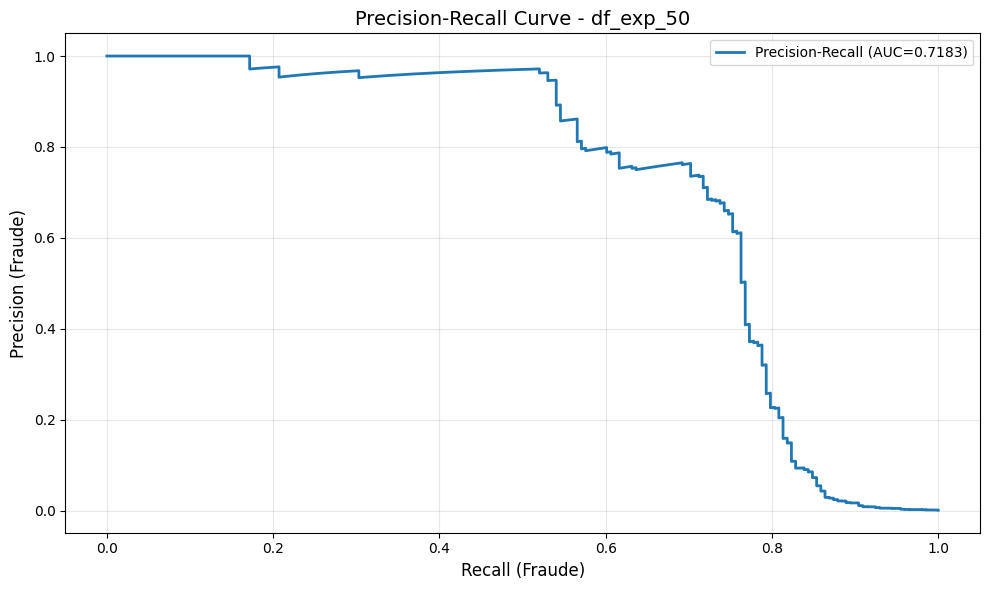

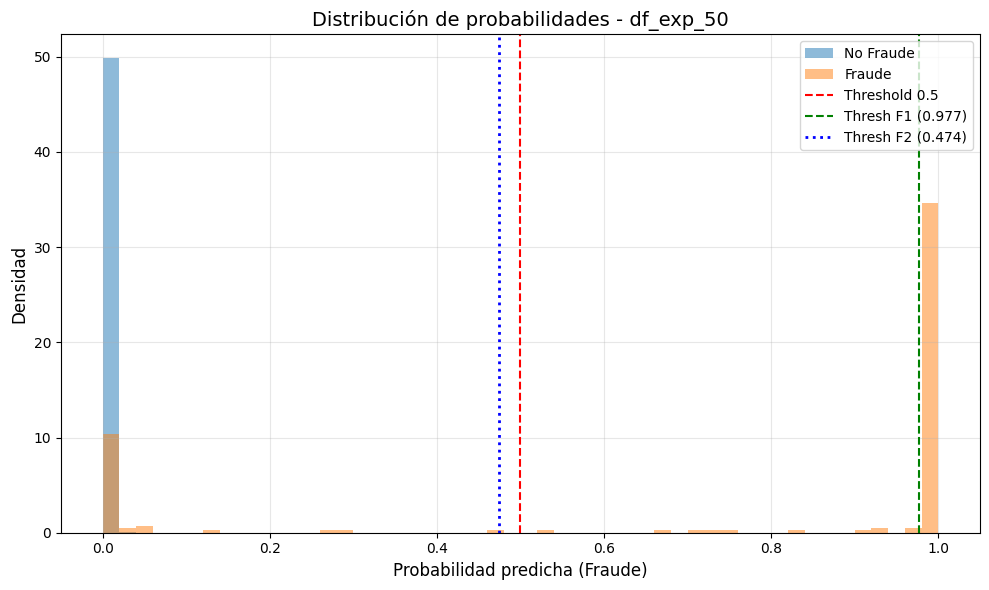


Distribución test: {0: 135134, 1: 198}
Fraudes en test: 198 (0.15%)

Análisis detallado: df_exp_random
Variables PCA disponibles: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares de variables con correlación >= 0.8: 0

Correlaciones con Class (ordenadas por |correlación|):
     Correlation_with_Class
V14                0.576213
V17                0.559115
V12                0.482525
V3                 0.441834
V10                0.425128
V16                0.402848
V7                 0.371840
V11                0.315465
V4                 0.277835
V18                0.259296
V1                 0.225838
V5                 0.218690
V9                 0.201004
V2                 0.196092
V21                0.148990
V27                0.122

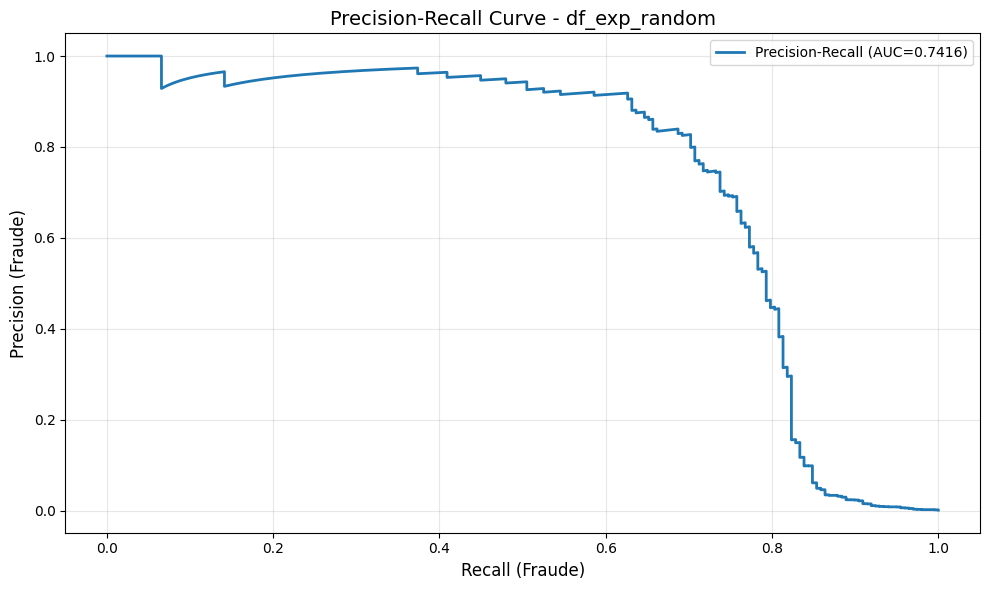

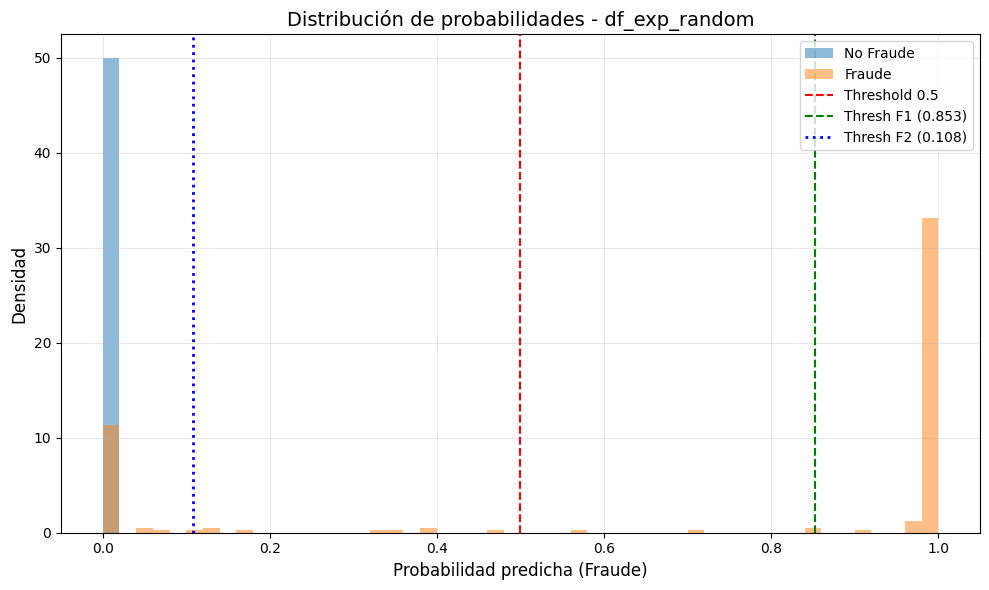


Distribución test: {0: 135134, 1: 198}
Fraudes en test: 198 (0.15%)

Análisis detallado: df_exp_63
Variables PCA disponibles: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares de variables con correlación >= 0.8: 38

Correlaciones con Class (ordenadas por |correlación|):
     Correlation_with_Class
V14                0.772652
V12                0.709711
V4                 0.698746
V10                0.691330
V11                0.683162
V16                0.638590
V17                0.609516
V3                 0.589876
V9                 0.565319
V7                 0.542446
V18                0.535189
V2                 0.526138
V1                 0.464362
V5                 0.436636
V6                 0.409015
V19                0.330211

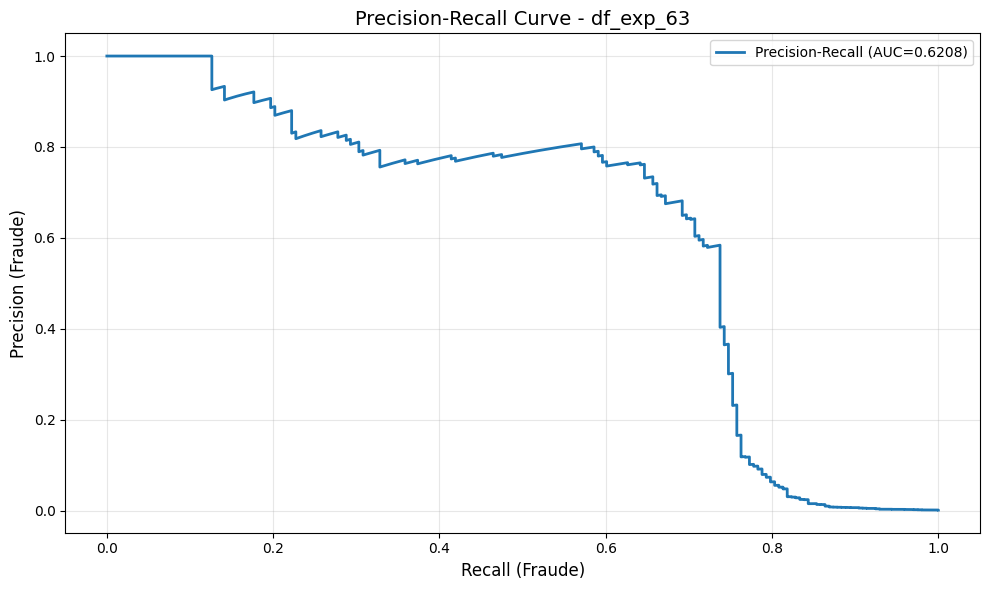

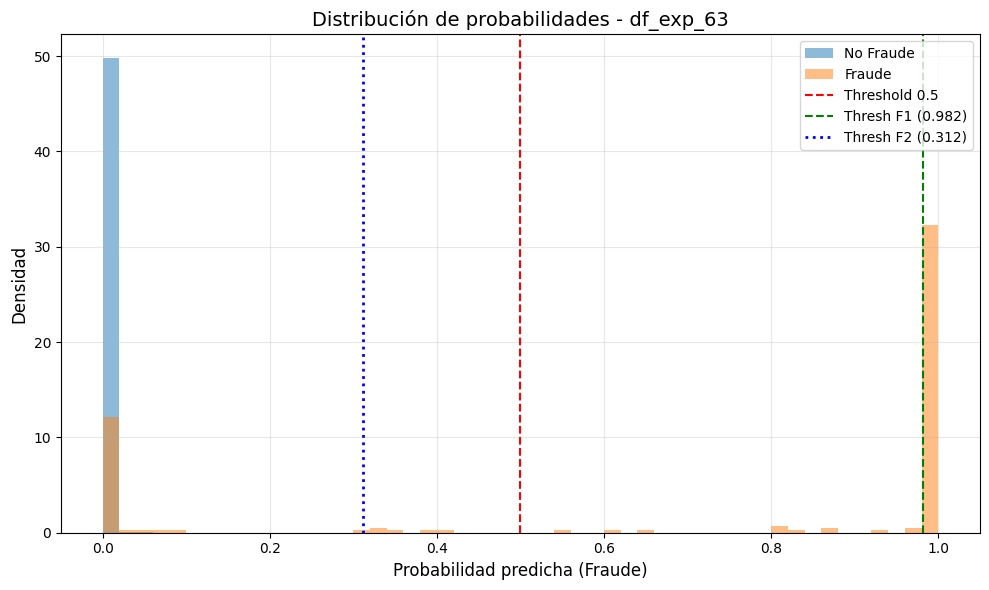


Distribución test: {0: 135134, 1: 198}
Fraudes en test: 198 (0.15%)

Análisis detallado: df_exp_same_prop
Variables PCA disponibles: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares de variables con correlación >= 0.8: 0

Correlaciones con Class (ordenadas por |correlación|):
     Correlation_with_Class
V14                0.575789
V17                0.556847
V12                0.483456
V3                 0.438228
V10                0.423072
V16                0.403500
V7                 0.368359
V11                0.314122
V4                 0.275406
V18                0.259000
V1                 0.225918
V5                 0.217913
V9                 0.197275
V2                 0.194694
V21                0.154926
V27                0.

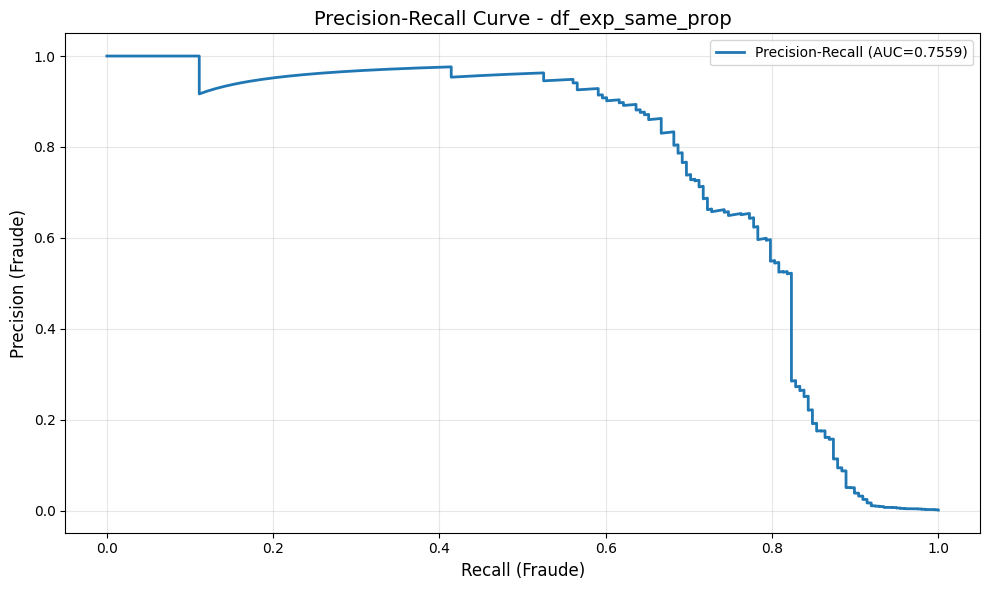

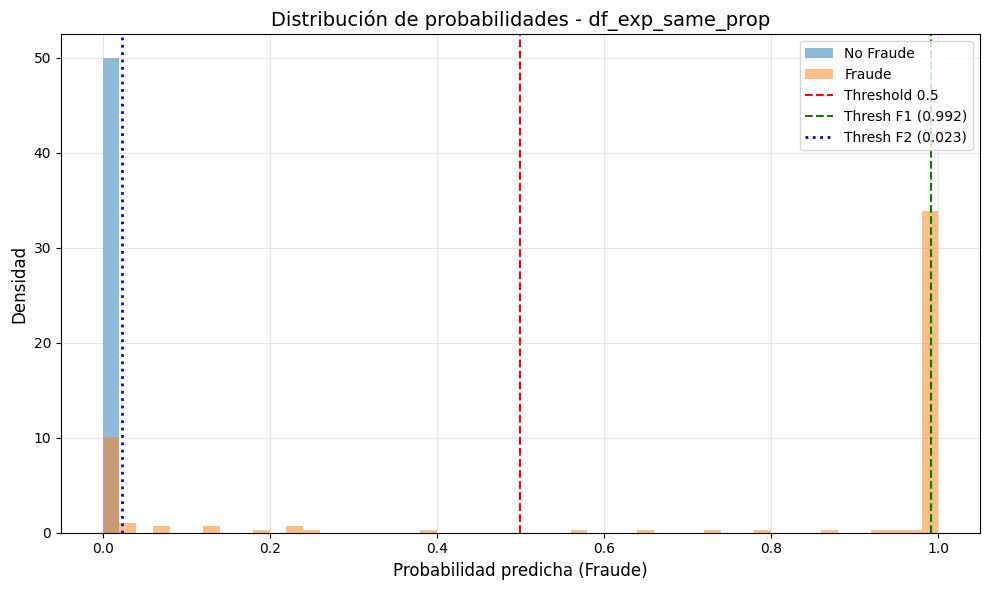


Distribución test: {0: 135134, 1: 198}
Fraudes en test: 198 (0.15%)

TABLA COMPARATIVA FINAL (Ordenada por F2-Score)
         dataset   auc_pr  f2_fraude_opt  recall_at_f2_opt  best_thresh_f2  f1_fraude_opt  roc_auc
df_exp_same_prop 0.755879       0.747398          0.797980        0.022993       0.752137 0.971842
   df_exp_random 0.741586       0.743310          0.757576        0.108057       0.759563 0.968971
       df_exp_50 0.718251       0.730392          0.752525        0.474460       0.731579 0.955187
       df_exp_63 0.620800       0.700576          0.737374        0.311567       0.699454 0.937718


In [ ]:
# ============================================================================
# Ejecución masiva de evaluación en los datasets experimentales
# ============================================================================

# 1. Definimos la lista de tuplas (dataframe, nombre)
df_exp_50 = pd.read_csv("df_exp_50.csv")
df_exp_random = pd.read_csv("df_exp_random.csv")
df_exp_63 = pd.read_csv("df_exp_63.csv")
df_exp_same_prop = pd.read_csv("df_exp_same_prop.csv")

datasets_to_evaluate = [
    (df_exp_50, 'df_exp_50'),
    (df_exp_random, 'df_exp_random'),
    (df_exp_63, 'df_exp_63'),
    (df_exp_same_prop, 'df_exp_same_prop')
]

# 2. Lista para acumular los resultados
results_list = []

# 3. Bucle de ejecución
for df_dataset, name_dataset in datasets_to_evaluate:
    try:
        # Ejecutamos la función con F2 incluido
        metrics = eval_desbalanceado_detallado1(df_dataset, name_dataset)

        # Si la función retorna datos (no está vacío por error), guardamos
        if metrics:
            results_list.append(metrics)

    except Exception as e:
        print(f"Error procesando {name_dataset}: {e}")

# ============================================================================
# Resumen Comparativo Final
# ============================================================================

if results_list:
    df_results = pd.DataFrame(results_list)

    # Columnas clave para mostrar en el resumen (priorizando F2 y Recall)
    cols_to_show = [
        'dataset',
        'auc_pr',
        'f2_fraude_opt',      # Tu métrica principal
        'recall_at_f2_opt',   # Recall asociado al mejor F2
        'best_thresh_f2',     # Threshold para lograr ese F2
        'f1_fraude_opt',      # Para comparar con la métrica balanceada estándar
        'roc_auc'
    ]

    # Filtrar solo columnas que existan (por seguridad)
    final_cols = [c for c in cols_to_show if c in df_results.columns]

    print("\n" + "="*80)
    print("TABLA COMPARATIVA FINAL (Ordenada por F2-Score)")
    print("="*80)

    # Ordenar por F2 Score descendente
    summary_sorted = df_results[final_cols].sort_values(by='f2_fraude_opt', ascending=False)

    # Imprimir
    print(summary_sorted.to_string(index=False))

else:
    print("No se generaron resultados para mostrar.")

## Próximos pasos después de comparar datasets sintéticos

Una vez que hayas ejecutado la celda anterior y decidido qué dataset sintético funciona mejor:

1. **Probar otros modelos** en el mejor dataset sintético:
   - Random Forest
   - XGBoost  
   - Logistic Regression (baseline)
   - Comparar con LightGBM usando las mismas métricas (AUC-PR, F1 fraude, Recall/Precision)

2. **Tuning de hiperparámetros** del mejor modelo:
   - RandomizedSearchCV para LightGBM (o el modelo ganador)
   - Optimizar para maximizar Recall de fraude o F1

3. **Interpretabilidad SHAP**:
   - ¿Qué features predicen fraude?
   - Visualizar decisiones del modelo

4. **Análisis de errores**:
   - Examinar falsos negativos (fraudes no detectados)
   - Examinar falsos positivos (alertas incorrectas)
   - Identificar patrones donde falla el modelo


In [ ]:
""""import pandas as pd
import numpy as np

def preprocess_desbalanceado(df_in: pd.DataFrame) -> tuple:
    """ """
    Ejecuta EXCLUSIVAMENTE el pipeline de preprocesamiento:
    1. Conversión de Timestamp a Date.
    2. Filtrado de variables PCA (V1-V28) y limpieza de NaNs.
    3. Split Temporal (Día 1 Train, Día 2 Test).
    4. Eliminación de variables altamente correlacionadas (>0.8) calculadas sobre el TRAIN.
    5. Desduplicación de filas.

    Retorna:
        (X_train, y_train, X_test, y_test, final_vars)
        O None si falla alguna validación. """
    """
    print(f"\n{'='*60}")
    print(f"Iniciando Preprocesamiento (Pipeline Extarído)")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 1. Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("Error: No hay columna 'timestamp'.")
        return None

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 2. Selección inicial de variables PCA (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]

    if not available_pca_vars:
        print("Error: No se encontraron variables V1-V28.")
        return None

    # Eliminar filas con NaN en las PCA o en Class
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 3. Split temporal (día 1 para train, día 2 para test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Error: Solo hay un día de datos; se requieren al menos 2 para el split.")
        return None

    train_date, test_date = dates[0], dates[1]
    print(f"Split Temporal -> Train: {train_date} | Test: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 4. Análisis de correlaciones (Calculado SOLO en TRAIN)
    # ---------------------------------------------------------------------
    pca_only_train = train_df.loc[:, available_pca_vars]

    # Matriz de correlación entre variables
    corr_matrix = pca_only_train.corr().abs()

    # Correlación con el Target
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    # Identificar pares con alta correlación
    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j])
                )

    # Decidir cuál eliminar basándose en la correlación con el Target
    vars_to_remove = set()
    for var1, var2 in high_corr_pairs:
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue

        corr1_target = abs(float(target_corr[var1]))
        corr2_target = abs(float(target_corr[var2]))

        if corr1_target >= corr2_target:
            vars_to_remove.add(var2) # Se va la que tiene menos correlación con el target
        else:
            vars_to_remove.add(var1)

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]
    print(f"Variables iniciales: {len(available_pca_vars)} -> Eliminadas: {len(vars_to_remove)} -> Finales: {len(final_pca_vars)}")

    # ---------------------------------------------------------------------
    # 5. Desduplicar usando variables finales
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    # ---------------------------------------------------------------------
    # Preparar salida
    # ---------------------------------------------------------------------
    X_train = train_df[final_pca_vars]
    y_train = train_df['Class']
    X_test = test_df[final_pca_vars]
    y_test = test_df['Class']

    print(f"Shape final -> X_train: {X_train.shape}, X_test: {X_test.shape}")

    return X_train, y_train, X_test, y_test, final_pca_vars""""

In [7]:
# ============================================================================
# Análisis detallado con Random Forest para desbalance extremo
# ============================================================================
def eval_desbalanceado_rf(df_in: pd.DataFrame, name: str) -> dict:
    print(f"\n{'='*60}")
    print(f"Análisis detallado (Random Forest): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No hay timestamp; se omite.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Selección inicial de variables PCA (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No hay V1-V28; se omite.")
        return {}

    print(f"Variables PCA disponibles: {len(available_pca_vars)} -> {available_pca_vars}")

    # Eliminar filas con NaN
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 2) Split temporal (día 1 train, día 2 test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Solo hay un día; no se evalúa.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 3) Análisis de correlaciones
    # ---------------------------------------------------------------------
    print("\n=== Análisis de correlaciones entre variables PCA ===")
    pca_only_train = train_df.loc[:, available_pca_vars]
    corr_matrix = pca_only_train.corr().abs()

    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )
    print(f"Pares con correlación >= {threshold_corr}: {len(high_corr_pairs)}")

    # Correlaciones con el target en TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    # ---------------------------------------------------------------------
    # 4) Eliminar PCA muy correlacionadas entre sí
    # ---------------------------------------------------------------------
    vars_to_remove = set()

    for var1, var2, corr_val in high_corr_pairs:
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue

        c1 = abs(float(target_corr[var1]))
        c2 = abs(float(target_corr[var2]))

        if c1 >= c2:
            vars_to_remove.add(var2)
        else:
            vars_to_remove.add(var1)

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]
    print(f"Variables eliminadas: {len(vars_to_remove)}")
    print(f"Variables finales: {len(final_pca_vars)}")

    if not final_pca_vars:
        return {}

    # ---------------------------------------------------------------------
    # 5) Desduplicar y preparar X, y
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    X_train = train_df[final_pca_vars]
    y_train = train_df['Class']
    X_test = test_df[final_pca_vars]
    y_test = test_df['Class']

    # ---------------------------------------------------------------------
    # 6) Entrenar Random Forest
    # ---------------------------------------------------------------------
    # class_weight='balanced' es vital aquí para sustituir la lógica de scale_pos_weight
    model = RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        max_depth=15,             # Limitamos profundidad para evitar overfitting en ruido
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',  # <--- Importante para desbalance
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    print("\nEntrenando Random Forest...")
    model.fit(X_train, y_train)

    # Predicciones (probabilidad de clase 1)
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Métricas Standard (Threshold 0.5)
    # ---------------------------------------------------------------------
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)

    tn, fp, fn, tp = cm_05.ravel()

    rec_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    f1_05 = 2 * (prec_05 * rec_05) / (prec_05 + rec_05) if (prec_05 + rec_05) > 0 else 0.0

    # F2 Score (Recall pesa más)
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print("\n--- Matriz de Confusión (RF @ 0.5) ---")
    print(f"TN: {tn} | FP: {fp}")
    print(f"FN: {fn} | TP: {tp}")
    print(f"F2 Score: {f2_05:.4f}")

    # ---------------------------------------------------------------------
    # 8) Curvas y AUC
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"AUC-PR: {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # ---------------------------------------------------------------------
    # 9) Threshold Óptimo (Maximizar F2)
    # ---------------------------------------------------------------------
    scores_list = []
    # thresholds_pr tiene n_thresholds, precision/recall tienen n+1.
    # Iteramos con zip seguro
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):

        # Calculamos F2 manualmente para cada punto de la curva
        denom = (4 * prec_th) + rec_th
        if denom > 0:
            f2_val = 5 * (prec_th * rec_th) / denom
        else:
            f2_val = 0.0

        scores_list.append((thresh, prec_th, rec_th, f2_val))

    # Inicializar
    best_thresh_f2 = 0.5
    best_f2_score = 0.0
    best_rec_f2 = 0.0
    best_prec_f2 = 0.0

    if scores_list:
        # Tupla: (thresh, prec, rec, f2) -> Indice 3 es F2
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

        # Recalcular TP/FP para reporte exacto con ese threshold
        y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
        cm_opt = confusion_matrix(y_test, y_pred_opt)
        tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

        print(f"\n--- Threshold Óptimo RF (Max F2) ---")
        print(f"Threshold: {best_thresh_f2:.4f}")
        print(f"F2 Score:  {best_f2_score:.4f}")
        print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
        print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 10) Gráficas
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'RF PR Curve (AUC={auc_pr:.4f})', color='green', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - Random Forest - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraude', density=True, color='skyblue')
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraude', density=True, color='orange')
    plt.axvline(x=0.5, color='red', linestyle='--', label='Thresh 0.5')
    plt.axvline(x=best_thresh_f2, color='green', linestyle=':', linewidth=2, label=f'Best F2 ({best_thresh_f2:.3f})')
    plt.xlabel('Probabilidad (RF)')
    plt.title(f'Distribución de Probabilidades - {name}')
    plt.legend()
    plt.show()

    return {
        'dataset': name,
        'model': 'RandomForest',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Análisis detallado (Random Forest): df_exp_50
Variables PCA disponibles: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares con correlación >= 0.8: 38
Variables eliminadas: 12
Variables finales: 16

Entrenando Random Forest...

--- Matriz de Confusión (RF @ 0.5) ---
TN: 135102 | FP: 32
FN: 69 | TP: 129
F2 Score: 0.6768
AUC-PR: 0.6882
ROC-AUC: 0.9680

--- Threshold Óptimo RF (Max F2) ---
Threshold: 0.3613
F2 Score:  0.7280
Recall:    0.7273 (TP: 144)
Precision: 0.7310 (FP: 53)


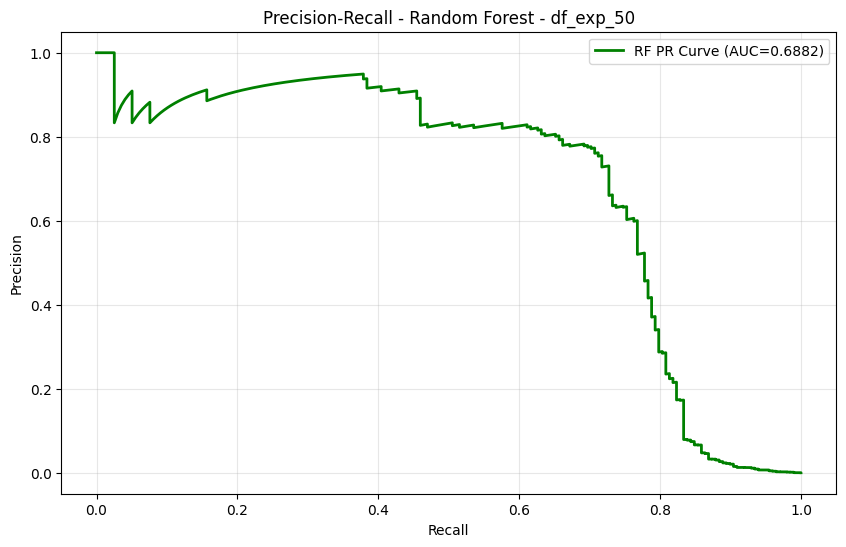

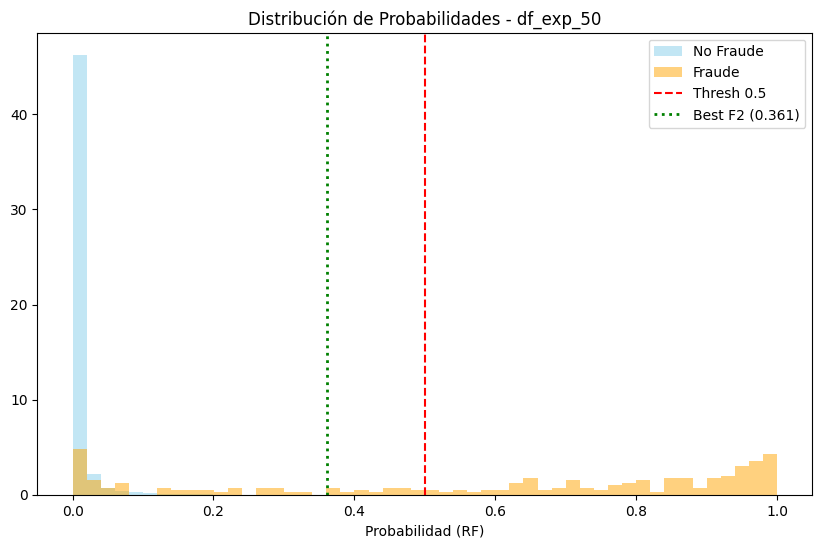


Análisis detallado (Random Forest): df_exp_random
Variables PCA disponibles: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares con correlación >= 0.8: 0
Variables eliminadas: 0
Variables finales: 28

Entrenando Random Forest...

--- Matriz de Confusión (RF @ 0.5) ---
TN: 135122 | FP: 12
FN: 58 | TP: 140
F2 Score: 0.7415
AUC-PR: 0.7816
ROC-AUC: 0.9584

--- Threshold Óptimo RF (Max F2) ---
Threshold: 0.3097
F2 Score:  0.7895
Recall:    0.7727 (TP: 153)
Precision: 0.8644 (FP: 24)


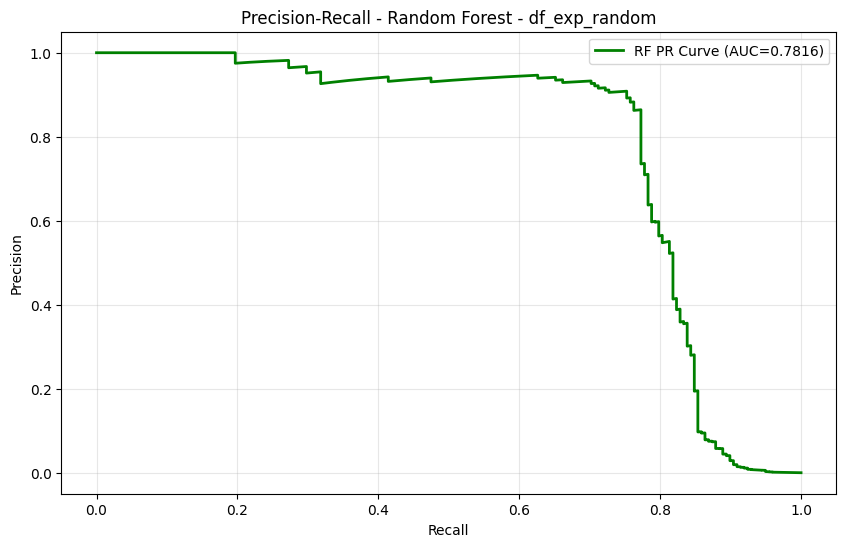

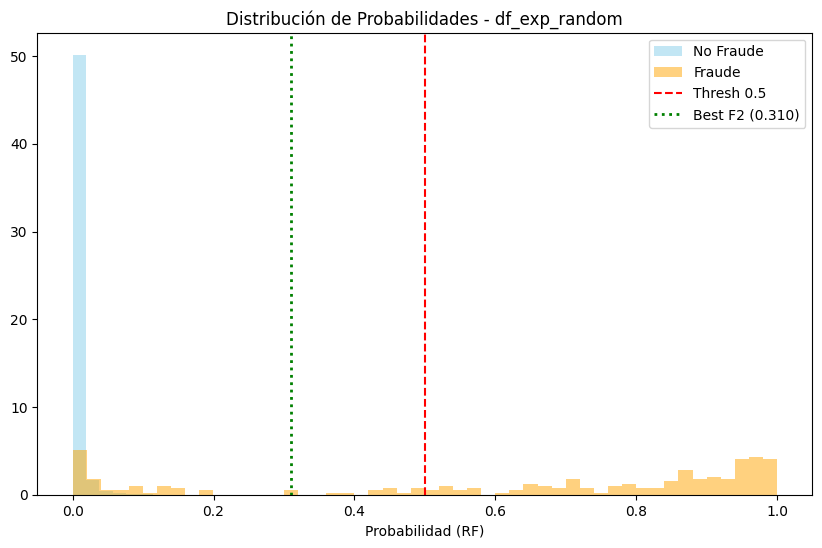


Análisis detallado (Random Forest): df_exp_63
Variables PCA disponibles: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares con correlación >= 0.8: 38
Variables eliminadas: 13
Variables finales: 15

Entrenando Random Forest...

--- Matriz de Confusión (RF @ 0.5) ---
TN: 135103 | FP: 31
FN: 89 | TP: 109
F2 Score: 0.5848
AUC-PR: 0.6165
ROC-AUC: 0.9616

--- Threshold Óptimo RF (Max F2) ---
Threshold: 0.3160
F2 Score:  0.7001
Recall:    0.7121 (TP: 141)
Precision: 0.6558 (FP: 74)


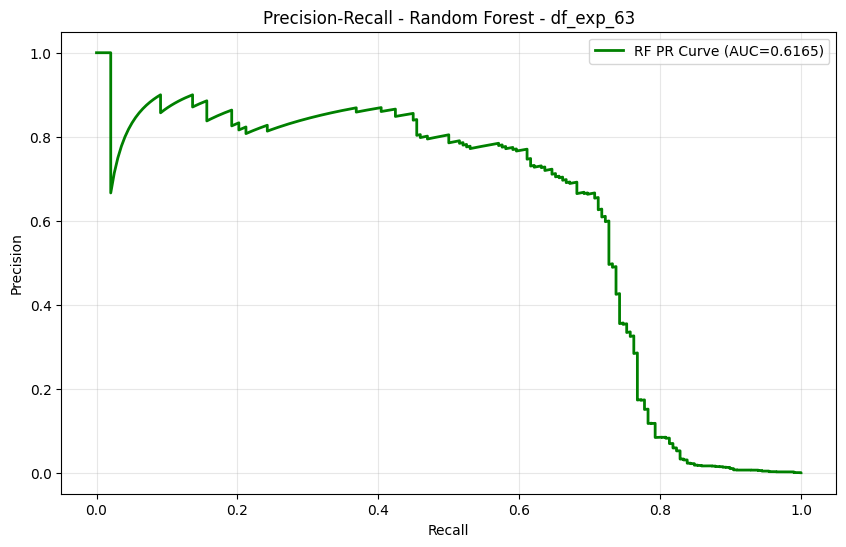

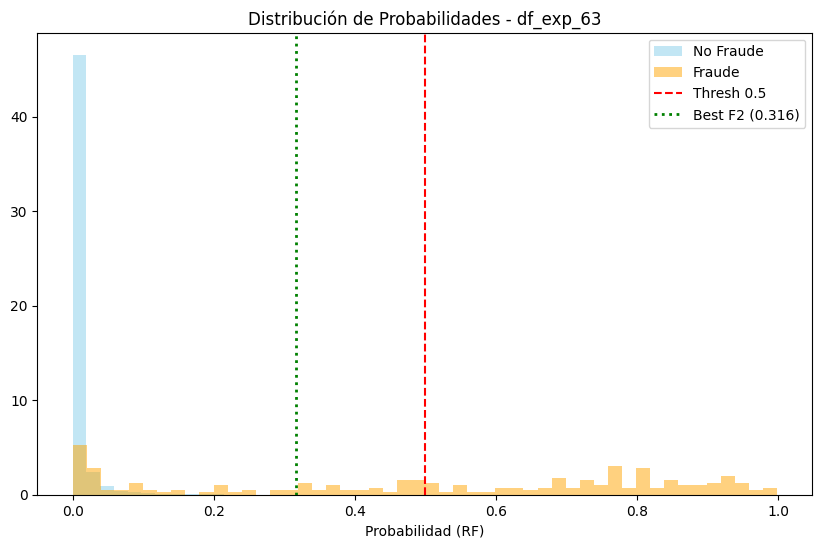


Análisis detallado (Random Forest): df_exp_same_prop
Variables PCA disponibles: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares con correlación >= 0.8: 0
Variables eliminadas: 0
Variables finales: 28

Entrenando Random Forest...

--- Matriz de Confusión (RF @ 0.5) ---
TN: 135122 | FP: 12
FN: 56 | TP: 142
F2 Score: 0.7505
AUC-PR: 0.7760
ROC-AUC: 0.9646

--- Threshold Óptimo RF (Max F2) ---
Threshold: 0.2997
F2 Score:  0.7843
Recall:    0.7677 (TP: 152)
Precision: 0.8588 (FP: 25)


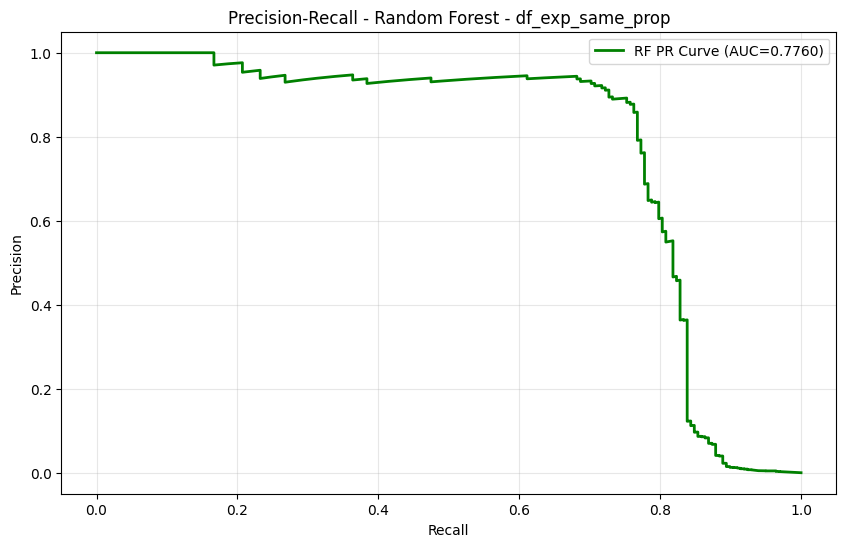

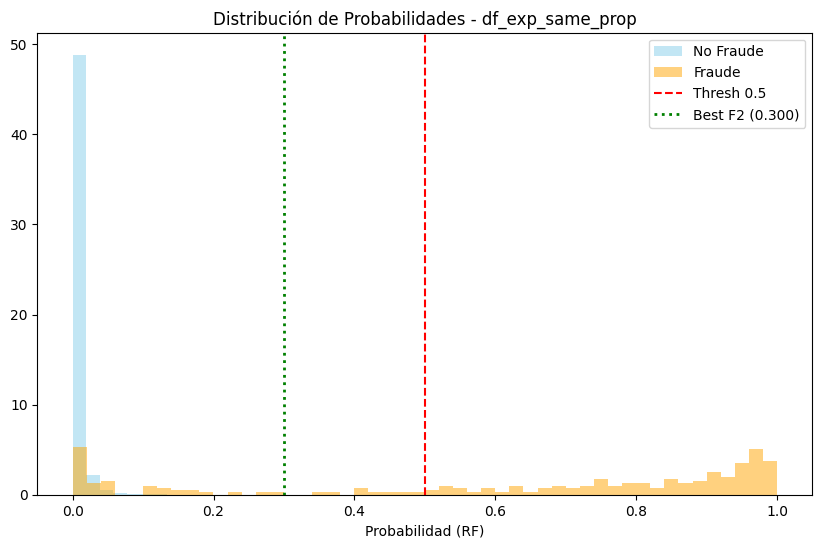


Análisis detallado (Random Forest): df_exp_50_1
Variables PCA disponibles: 16 -> ['V4', 'V6', 'V8', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares con correlación >= 0.8: 1
Variables eliminadas: 1
Variables finales: 15

Entrenando Random Forest...

--- Matriz de Confusión (RF @ 0.5) ---
TN: 135207 | FP: 39
FN: 73 | TP: 125
F2 Score: 0.6538
AUC-PR: 0.6586
ROC-AUC: 0.9688

--- Threshold Óptimo RF (Max F2) ---
Threshold: 0.2913
F2 Score:  0.7283
Recall:    0.7525 (TP: 149)
Precision: 0.6450 (FP: 82)


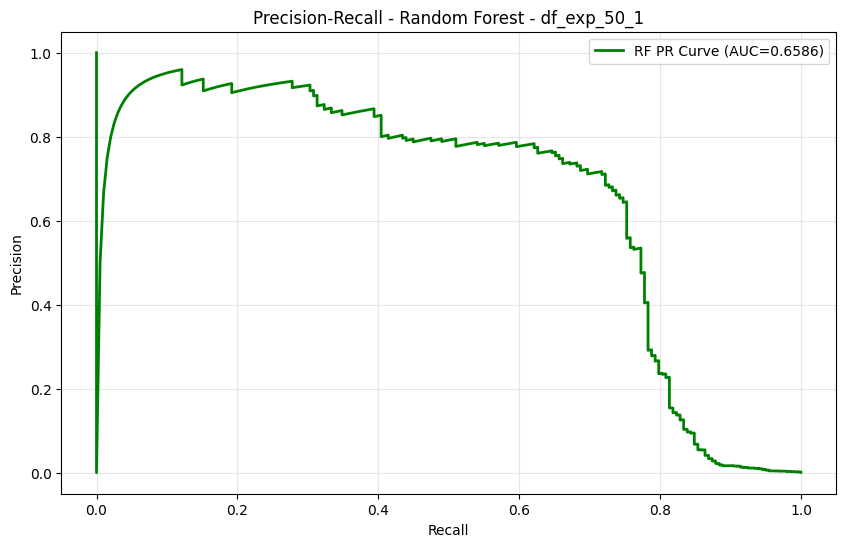

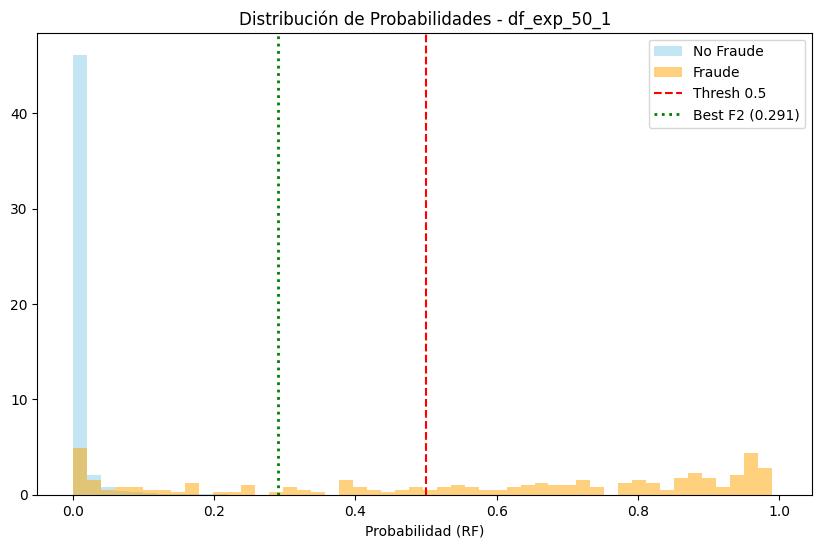


Análisis detallado (Random Forest): df_exp_random_1
Variables PCA disponibles: 16 -> ['V4', 'V6', 'V8', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares con correlación >= 0.8: 0
Variables eliminadas: 0
Variables finales: 16

Entrenando Random Forest...

--- Matriz de Confusión (RF @ 0.5) ---
TN: 135207 | FP: 39
FN: 67 | TP: 131
F2 Score: 0.6809
AUC-PR: 0.6731
ROC-AUC: 0.9522

--- Threshold Óptimo RF (Max F2) ---
Threshold: 0.3485
F2 Score:  0.7264
Recall:    0.7374 (TP: 146)
Precision: 0.6854 (FP: 67)


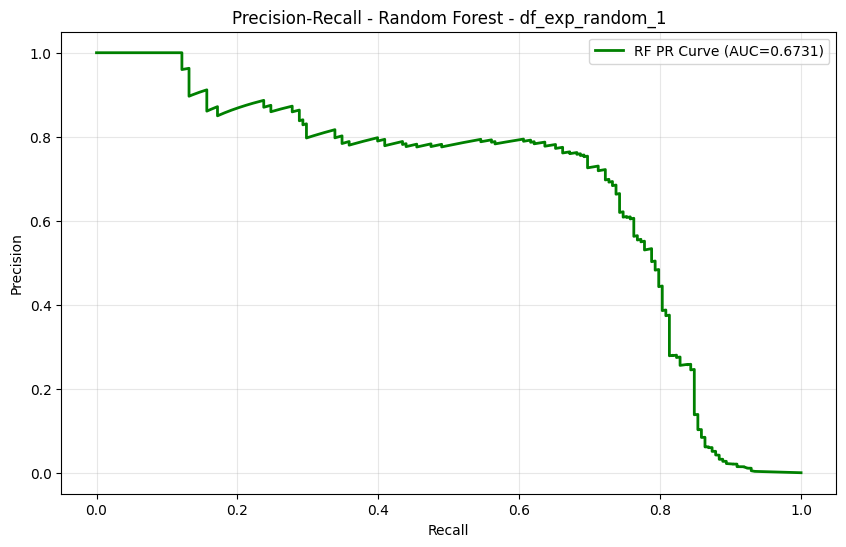

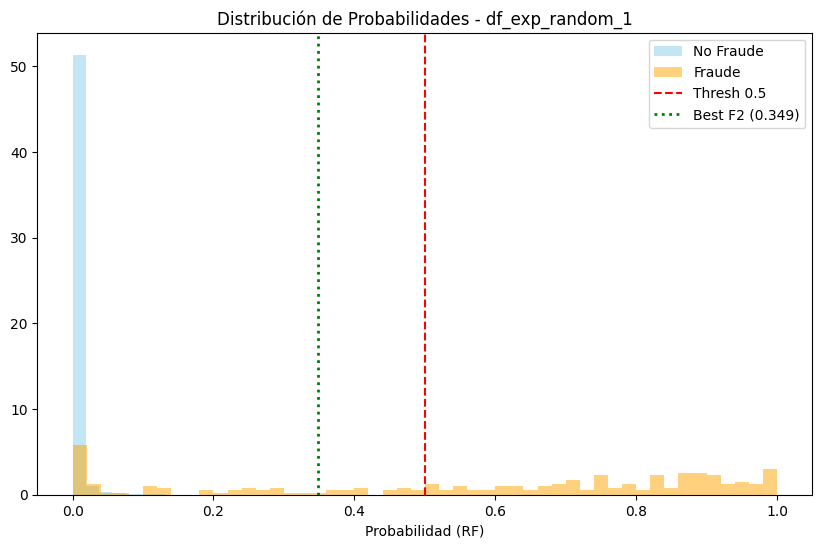


Análisis detallado (Random Forest): df_exp_63_1
Variables PCA disponibles: 16 -> ['V4', 'V6', 'V8', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares con correlación >= 0.8: 2
Variables eliminadas: 2
Variables finales: 14

Entrenando Random Forest...

--- Matriz de Confusión (RF @ 0.5) ---
TN: 135209 | FP: 37
FN: 87 | TP: 111
F2 Score: 0.5904
AUC-PR: 0.5870
ROC-AUC: 0.9619

--- Threshold Óptimo RF (Max F2) ---
Threshold: 0.3587
F2 Score:  0.6707
Recall:    0.6768 (TP: 134)
Precision: 0.6473 (FP: 73)


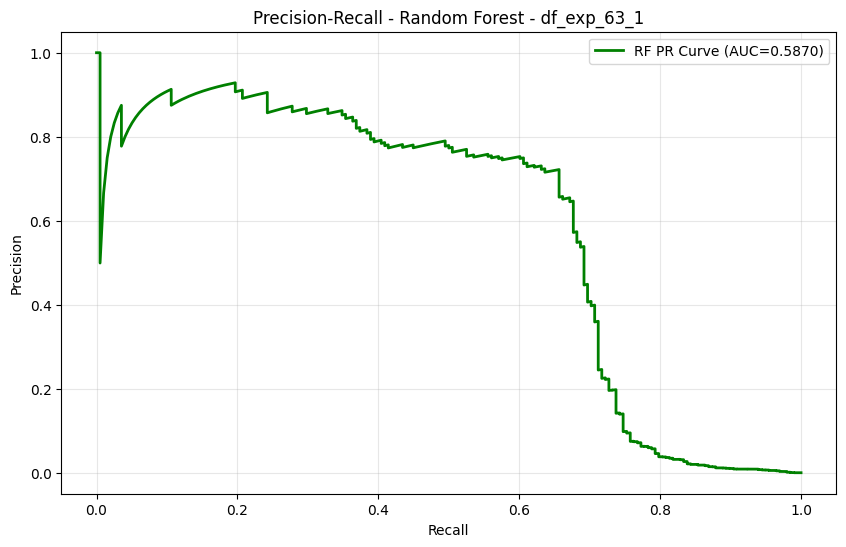

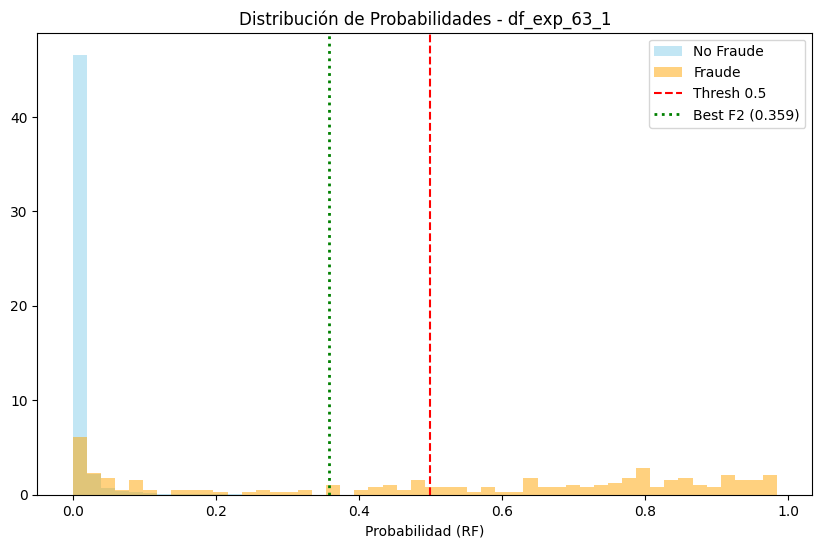


Análisis detallado (Random Forest): df_exp_same_prop_1
Variables PCA disponibles: 16 -> ['V4', 'V6', 'V8', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones entre variables PCA ===
Pares con correlación >= 0.8: 0
Variables eliminadas: 0
Variables finales: 16

Entrenando Random Forest...

--- Matriz de Confusión (RF @ 0.5) ---
TN: 135205 | FP: 41
FN: 72 | TP: 126
F2 Score: 0.6569
AUC-PR: 0.6618
ROC-AUC: 0.9570

--- Threshold Óptimo RF (Max F2) ---
Threshold: 0.2595
F2 Score:  0.7358
Recall:    0.7879 (TP: 156)
Precision: 0.5821 (FP: 112)


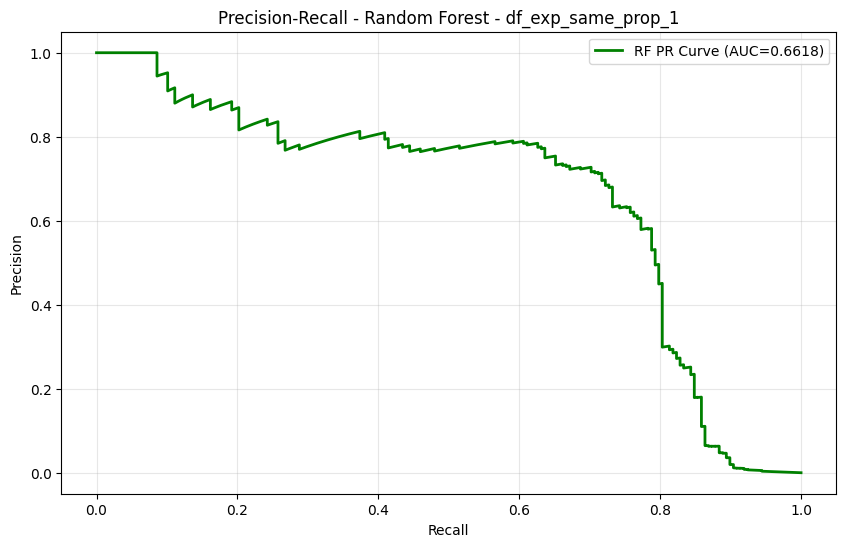

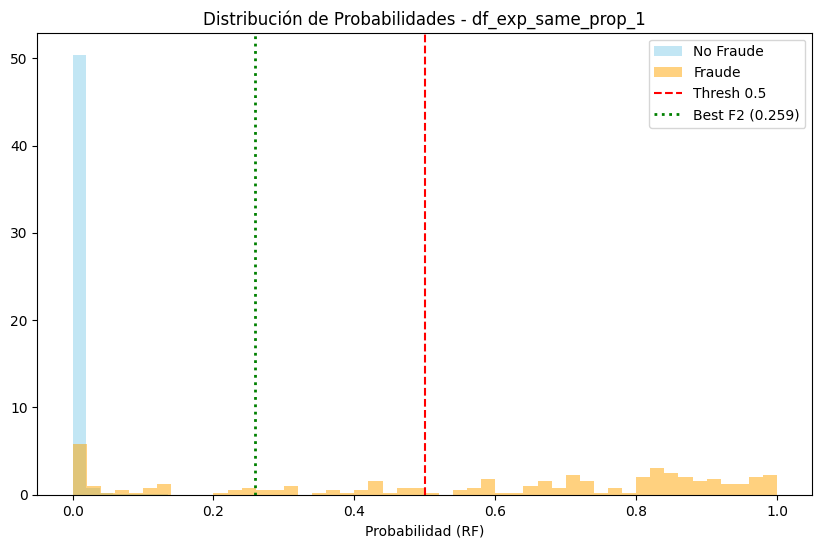


TABLA COMPARATIVA FINAL (Ordenada por F2-Score)
           dataset   auc_pr  f2_fraude_opt  recall_at_f2_opt  best_thresh_f2  roc_auc
     df_exp_random 0.781591       0.789474          0.772727        0.309667 0.958376
  df_exp_same_prop 0.776049       0.784314          0.767677        0.299719 0.964634
df_exp_same_prop_1 0.661755       0.735849          0.787879        0.259478 0.956954
       df_exp_50_1 0.658558       0.728250          0.752525        0.291283 0.968788
         df_exp_50 0.688162       0.728008          0.727273        0.361349 0.967975
   df_exp_random_1 0.673075       0.726368          0.737374        0.348518 0.952154
         df_exp_63 0.616465       0.700099          0.712121        0.315988 0.961580
       df_exp_63_1 0.587015       0.670671          0.676768        0.358717 0.961889


In [9]:
# ============================================================================
# Ejecución masiva de evaluación en los datasets experimentales
# ============================================================================

# 1. Definimos la lista de tuplas (dataframe, nombre)
df_exp_50 = pd.read_csv("df_exp_50.csv")
df_exp_random = pd.read_csv("df_exp_random.csv")
df_exp_63 = pd.read_csv("df_exp_63.csv")
df_exp_same_prop = pd.read_csv("df_exp_same_prop.csv")

df_exp_50_1 = pd.read_csv("df_exp_501.csv")
df_exp_random_1 = pd.read_csv("df_exp_random1.csv")
df_exp_63_1 = pd.read_csv("df_exp_631.csv")
df_exp_same_prop_1 = pd.read_csv("df_exp_same_prop1.csv")

datasets_to_evaluate = [
    (df_exp_50, 'df_exp_50'),
    (df_exp_random, 'df_exp_random'),
    (df_exp_63, 'df_exp_63'),
    (df_exp_same_prop, 'df_exp_same_prop'),
    (df_exp_50_1, 'df_exp_50_1'),
    (df_exp_random_1, 'df_exp_random_1'),
    (df_exp_63_1, 'df_exp_63_1'),
    (df_exp_same_prop_1, 'df_exp_same_prop_1')
]

# 2. Lista para acumular los resultados
results_list = []

# 3. Bucle de ejecución
for df_dataset, name_dataset in datasets_to_evaluate:
    try:
        # Ejecutamos la función con F2 incluido
        metrics = eval_desbalanceado_rf(df_dataset, name_dataset)

        # Si la función retorna datos (no está vacío por error), guardamos
        if metrics:
            results_list.append(metrics)

    except Exception as e:
        print(f"Error procesando {name_dataset}: {e}")

# ============================================================================
# Resumen Comparativo Final
# ============================================================================

if results_list:
    df_results = pd.DataFrame(results_list)

    # Columnas clave para mostrar en el resumen (priorizando F2 y Recall)
    cols_to_show = [
        'dataset',
        'auc_pr',
        'f2_fraude_opt',      # Tu métrica principal
        'recall_at_f2_opt',   # Recall asociado al mejor F2
        'best_thresh_f2',     # Threshold para lograr ese F2
        'f1_fraude_opt',      # Para comparar con la métrica balanceada estándar
        'roc_auc'
    ]

    # Filtrar solo columnas que existan (por seguridad)
    final_cols = [c for c in cols_to_show if c in df_results.columns]

    print("\n" + "="*80)
    print("TABLA COMPARATIVA FINAL (Ordenada por F2-Score)")
    print("="*80)

    # Ordenar por F2 Score descendente
    summary_sorted = df_results[final_cols].sort_values(by='f2_fraude_opt', ascending=False)

    # Imprimir
    print(summary_sorted.to_string(index=False))

else:
    print("No se generaron resultados para mostrar.")

### Añadir más variables a parte de las del PCA?

In [10]:
df = df_exp_same_prop.copy()
df1 = df_exp_random.copy()

In [ ]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,tx_per_customer,tx_rate,merchant_fraud_rate,country_fraud_rate,geo_anomaly,device_change,browser_change,shared_ip,amount_log,is_outlier_amount
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,-0.133993,0.029913,0.248294,0.081086,-0.137806,0.025226,-0.080747,0.030543,-0.051725,-0.039541,...,286.991637,0.397490,0.007103,0.006991,0.995890,0.709629,0.619651,0.000086,3.164862,0.113147
std,1.985983,1.677042,1.623938,1.429797,1.421064,1.320563,1.360756,1.322377,1.125260,1.203206,...,16.347788,0.340955,0.065611,0.000373,0.063978,0.453947,0.485483,0.009273,1.666818,0.316773
min,-56.407510,-72.718107,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.226056,-13.434066,-24.588262,...,238.494923,0.122485,-0.002800,0.006382,-0.001769,-0.018217,-0.021917,-0.000393,-0.063959,-0.013237
25%,-0.977104,-0.579382,-0.400939,-0.793279,-0.794556,-0.726776,-0.584137,-0.175996,-0.683204,-0.524643,...,276.000000,0.187766,0.000000,0.006704,1.000000,0.002085,0.000000,0.000000,1.893358,0.000000
50%,-0.105755,0.088492,0.462063,0.068794,-0.177506,-0.235071,-0.010369,0.049230,-0.100097,-0.099827,...,287.000000,0.263507,0.000000,0.006896,1.000000,1.000000,0.999430,0.000000,3.161272,0.000000
75%,1.214317,0.806793,1.198816,0.878394,0.455765,0.422153,0.499732,0.351692,0.551523,0.436780,...,298.000000,0.453287,0.000168,0.007056,1.000000,1.000000,1.000000,0.000000,4.382027,0.001144
max,2.454930,22.057729,9.382558,16.875344,34.814764,73.301626,120.589494,20.027754,15.595433,23.747468,...,335.429424,2.222460,1.001947,0.007613,1.002780,1.021217,1.022647,1.000115,10.153941,1.012866


--- Split Temporal ---
Train Date: 2023-01-01
Test Date:  2023-01-02
Train shape: (359451, 66), Test shape: (140549, 66)


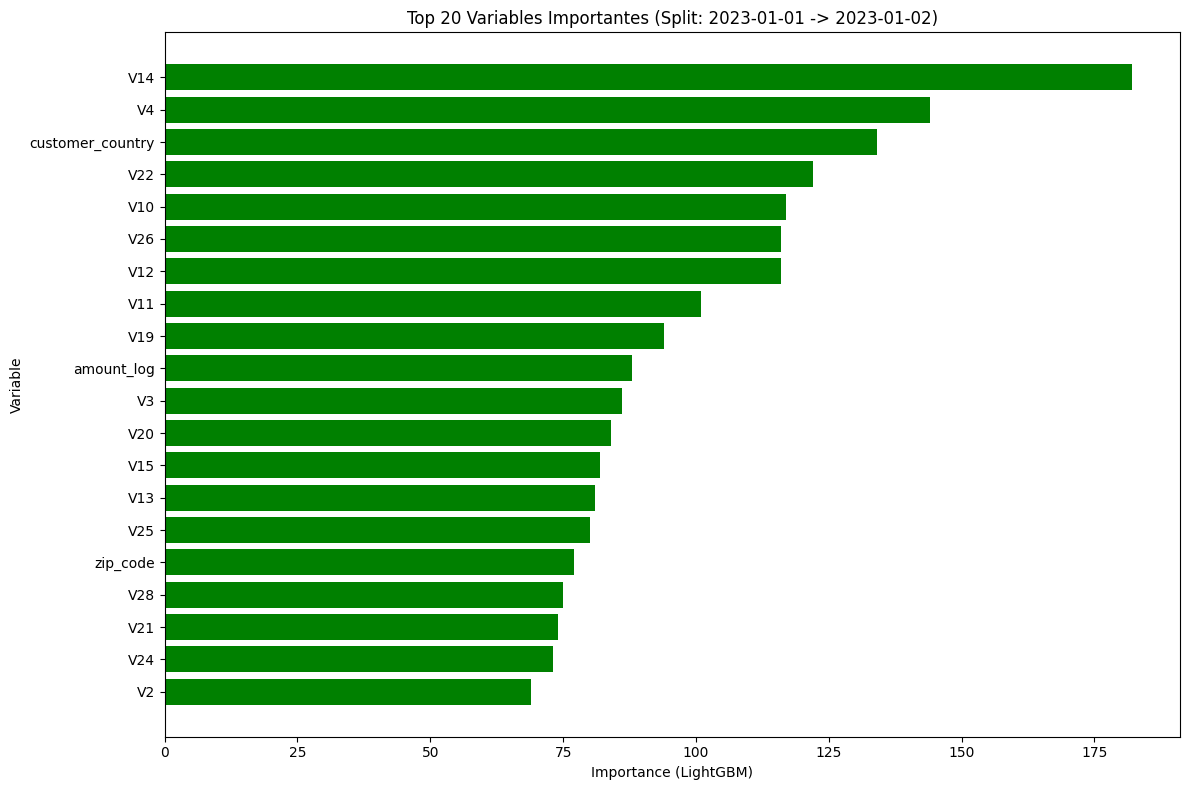

Vars: 1 | F2-score: 0.2259 | Recall: 0.8800 | AUC: 0.9303
Vars: 5 | F2-score: 0.7015 | Recall: 0.7774 | AUC: 0.8994
Vars: 10 | F2-score: 0.7658 | Recall: 0.7821 | AUC: 0.9226
Vars: 15 | F2-score: 0.7297 | Recall: 0.7424 | AUC: 0.8757
Vars: 20 | F2-score: 0.6928 | Recall: 0.7156 | AUC: 0.9005
Vars: 25 | F2-score: 0.6805 | Recall: 0.7378 | AUC: 0.8804
Vars: 30 | F2-score: 0.6694 | Recall: 0.7448 | AUC: 0.9032
Vars: 35 | F2-score: 0.6808 | Recall: 0.7611 | AUC: 0.8973
Vars: 40 | F2-score: 0.6829 | Recall: 0.7424 | AUC: 0.8873
Vars: 45 | F2-score: 0.6729 | Recall: 0.7879 | AUC: 0.9232
Vars: 50 | F2-score: 0.6867 | Recall: 0.7925 | AUC: 0.9311
Vars: 55 | F2-score: 0.7021 | Recall: 0.7844 | AUC: 0.9157
Vars: 60 | F2-score: 0.6853 | Recall: 0.7821 | AUC: 0.9190
Vars: 65 | F2-score: 0.6941 | Recall: 0.7844 | AUC: 0.9179


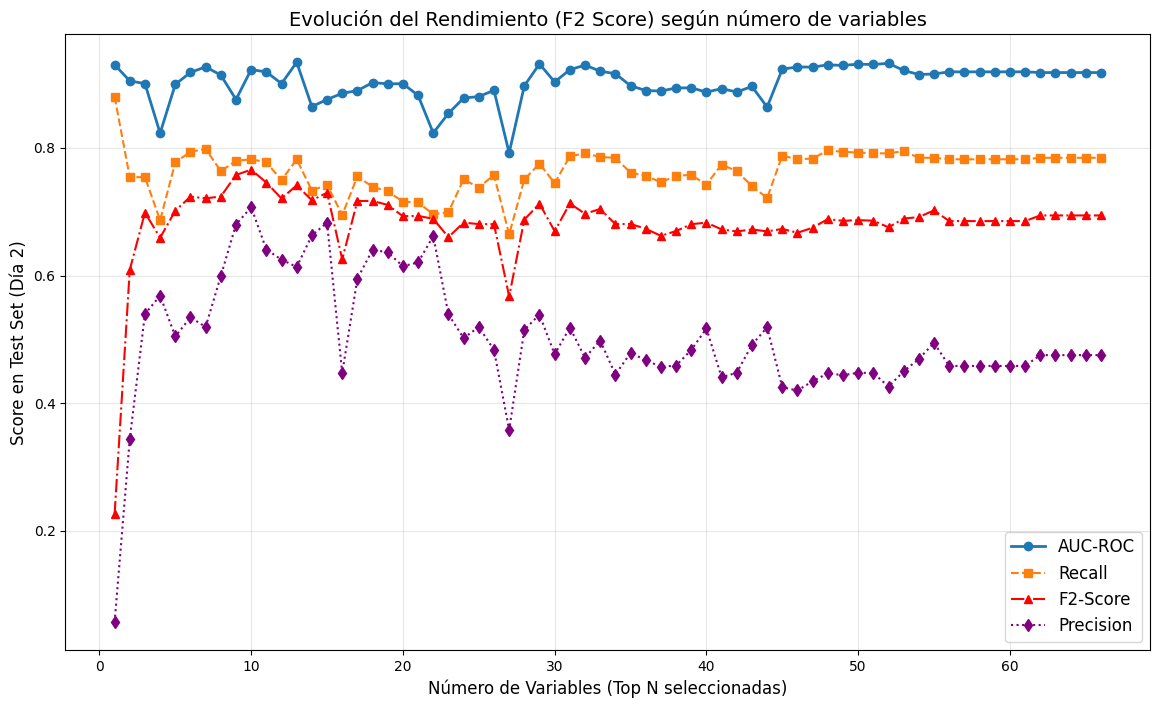

In [ ]:
import lightgbm as lgbm
#
# Importamos fbeta_score para calcular el F2
from sklearn.metrics import roc_auc_score, recall_score, fbeta_score, precision_score

# ============================================================================
# 1. Preparación de Datos con Split Temporal (Día 1 vs Día 2)
# ============================================================================

# Aseguramos que timestamp sea datetime y extraemos la fecha
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['date'] = df['timestamp'].dt.date

# Identificar los días disponibles
dates = sorted(df['date'].dropna().unique())

if len(dates) < 2:
    raise ValueError("El dataset necesita al menos 2 días distintos para hacer este split.")

train_date = dates[0]
test_date = dates[1]

print(f"--- Split Temporal ---")
print(f"Train Date: {train_date}")
print(f"Test Date:  {test_date}")

# Crear DataFrames de Train y Test
train_df = df[df['date'] == train_date].copy()
test_df = df[df['date'] == test_date].copy()

# Definir Columnas a eliminar (incluyendo las generadas para el split)
TARGET_COLUMN = 'Class'
COLS_TO_EXCLUDE = [
    TARGET_COLUMN, 'transaction_id', 'customer_id', 'device_id',
    'email', 'phone', 'name', 'timestamp', 'date',
    'country_fraud_rate', "merchant_fraud_rate"
]

# Separar X e y
y_train = train_df[TARGET_COLUMN]
X_train = train_df.drop(columns=COLS_TO_EXCLUDE, errors='ignore')

y_test = test_df[TARGET_COLUMN]
X_test = test_df.drop(columns=COLS_TO_EXCLUDE, errors='ignore')

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Convertir variables categóricas a 'category' para LightGBM
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# ============================================================================
# 2. Entrenar Modelo Base para obtener Ranking de Importancia
# ============================================================================

lgbm_base = lgbm.LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_base.fit(X_train, y_train)

# Crear DataFrame de Importancia
importances = lgbm_base.feature_importances_
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sorted_features_LGBM = importance_df['Variable'].tolist()

# PLOT 1: Top 20 Feature Importances
top_20_features = importance_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(
    top_20_features['Variable'],
    top_20_features['Importance'],
    color='green'
)
plt.xlabel("Importance (LightGBM)")
plt.ylabel("Variable")
plt.title(f"Top 20 Variables Importantes (Split: {train_date} -> {test_date})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================
# 3. Evaluación Iterativa de Rendimiento (F2 Score)
# ============================================================================

metrics_results = {
    'num_vars': [],
    'auc': [],
    'recall': [],
    'f2': [],
    'precision': []
}

# Iterar sobre las features ordenadas
# sabemos que mas de 40 variables no vamos a usar, asi que lo cargamos hasta
# 40 variables
for k in range(1, 41, 1):

    # Seleccionar las top k variables
    selected_feats = sorted_features_LGBM[:k]

    # Entrenar nuevo modelo con subset de features
    model_k = lgbm.LGBMClassifier(
        is_unbalance=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model_k.fit(X_train[selected_feats], y_train)

    # Predecir
    probs_test = model_k.predict_proba(X_test[selected_feats])[:, 1]
    preds_test = model_k.predict(X_test[selected_feats])

    # Calcular Métricas
    metrics_results['num_vars'].append(k)

    try:
        metrics_results['auc'].append(roc_auc_score(y_test, probs_test))
    except:
        metrics_results['auc'].append(0)

    metrics_results['recall'].append(recall_score(y_test, preds_test, zero_division=0))
    metrics_results['precision'].append(precision_score(y_test, preds_test, zero_division=0))

    # --- CAMBIO CLAVE: CÁLCULO DE F2 ---
    # beta=2 prioriza el Recall sobre la Precision
    f2_val = fbeta_score(y_test, preds_test, beta=2, zero_division=0)
    metrics_results['f2'].append(f2_val)

    # Print de progreso con F2
    if k % 5 == 0 or k == 1:
        print(f"Vars: {k} | F2-score: {metrics_results['f2'][-1]:.4f} | Recall: {metrics_results['recall'][-1]:.4f} | AUC: {metrics_results['auc'][-1]:.4f}")

# PLOT 2: Curva de Rendimiento (Con F2)
plt.figure(figsize=(14, 8))

plt.plot(metrics_results['num_vars'], metrics_results['auc'], label='AUC-ROC', marker='o', linewidth=2)
plt.plot(metrics_results['num_vars'], metrics_results['recall'], label='Recall', marker='s', linestyle='--')
# Graficamos F2
plt.plot(metrics_results['num_vars'], metrics_results['f2'], label='F2-Score', marker='^', linestyle='-.', color='red')
plt.plot(metrics_results['num_vars'], metrics_results['precision'], label='Precision', marker='d', linestyle=':', color='purple')

plt.xlabel('Número de Variables (Top N seleccionadas)', fontsize=12)
plt.ylabel('Score en Test Set (Día 2)', fontsize=12)
plt.title('Evolución del Rendimiento (F2 Score) según número de variables', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(sorted_features_LGBM)

['V14', 'V4', 'customer_country', 'V22', 'V10', 'V26', 'V12', 'V11', 'V19', 'amount_log', 'V3', 'V20', 'V15', 'V13', 'V25', 'zip_code', 'V28', 'V21', 'V24', 'V2', 'V6', 'hour_sin', 'V7', 'V8', 'V18', 'merchant', 'V9', 'V27', 'V17', 'V23', 'V5', 'hour_cos', 'V16', 'V1', 'days_in_bank_log', 'secs_since_prev_tx', 'city', 'evening', 'credit_score', 'tx_per_customer', 'Amount', 'morning', 'afternoon', 'tx_rate', 'age', 'days_in_bank', 'is_outlier_amount', 'is_mobile', 'device_change', 'is_night_tx', 'main_browser', 'geo_anomaly', 'shared_ip', 'night', 'browser_change', 'is_foreign_tx', 'os', 'ip_address', 'merchant_country', 'is_weekend', 'device_type', 'is_high_amount', 'browser', 'time_of_day', 'tenure_bucket', 'main_device']


Añado las nuevas variables y veo como mejora

In [ ]:
variables_pca = [f'V{i}' for i in range(1, 29)]
variables_especificas = [ 'customer_country', 'amount_log', 'timestamp']

In [ ]:
VARIABLES_TO_KEEP = list(set(variables_especificas + variables_pca + ['Class']))

In [ ]:
print(VARIABLES_TO_KEEP)

['V15', 'V17', 'V22', 'V21', 'V6', 'V3', 'V25', 'Class', 'V8', 'V16', 'V5', 'V11', 'V1', 'timestamp', 'V12', 'V13', 'V14', 'V26', 'V28', 'V4', 'V9', 'V24', 'V27', 'V2', 'V10', 'V23', 'V18', 'V19', 'V20', 'amount_log', 'V7', 'customer_country']


In [ ]:
columnas_existentes = [c for c in VARIABLES_TO_KEEP if c in df_exp_same_prop.columns]

In [ ]:
df_same_prop_new = df_exp_same_prop[columnas_existentes].copy()

In [ ]:
def eval_desbalanceado_lgbm_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evalúa usando LIGHTGBM con métricas para desbalance extremo (F2).
    CORREGIDO: Maneja correctamente el One-Hot Encoding sin perder la fecha de referencia.
    """
    print(f"\n{'='*60}")
    print(f"Análisis detallado (LightGBM - Todas las variables): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Preparación de Fechas
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No hay timestamp; se omite.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Selección de Variables (Limpieza previa al encoding)
    # ---------------------------------------------------------------------

    # Definimos columnas que NO deben entrar al get_dummies (Metadata y Target)
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    # Filtramos para borrar solo las que existan en tu DF actual
    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    # X_raw solo debe tener las variables predictivas (numéricas o categóricas)
    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    print(f"Variables antes de encoding: {X_raw.shape[1]}")

    # ---------------------------------------------------------------------
    # 2) Preprocesamiento: One-Hot Encoding
    # ---------------------------------------------------------------------
    # Aplicamos dummies solo a las variables predictivas
    X_processed = pd.get_dummies(X_raw, drop_first=True)

    print(f"Variables tras Encoding: {X_processed.shape[1]}")

    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Split Temporal (día 1 train, día 2 test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: El dataset necesita al menos 2 días distintos.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    # Separar Train y Test usando la fecha
    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    # Al crear X_train/X_test, eliminamos la columna de referencia temporal
    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Limpieza de Correlaciones
    # ---------------------------------------------------------------------
    print("\n=== Análisis de correlaciones (Todas las vars) ===")

    corr_matrix = X_train.corr().abs()
    threshold_corr = 0.90

    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

    print(f"Variables eliminadas por alta correlación (> {threshold_corr}): {len(to_drop_corr)}")

    X_train = X_train.drop(columns=to_drop_corr)
    X_test = X_test.drop(columns=to_drop_corr)

    print(f"Variables finales para el modelo: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Entrenar LightGBM
    # ---------------------------------------------------------------------
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    print("\nEntrenando LightGBM...")
    model.fit(X_train, y_train)

    # Predicciones
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Métricas y Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Buscar el mejor F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f2_val))

    best_thresh_f2 = 0.5
    best_f2_score = 0.0
    best_rec_f2 = 0.0
    best_prec_f2 = 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

    # Recalcular matriz para el óptimo
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Métricas base (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Threshold Óptimo (Maximiza F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 7) Gráficas
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'PR Curve (AUC={auc_pr:.4f})', color='purple', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - LightGBM - {name}')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraude', density=True, color='skyblue')
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraude', density=True, color='orange')
    plt.axvline(x=best_thresh_f2, color='blue', linestyle=':', linewidth=2, label=f'Opt F2 ({best_thresh_f2:.3f})')
    plt.legend()
    plt.show()

    return {
        'dataset': name,
        'model': 'LightGBM_AllVars',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Análisis detallado (LightGBM - Todas las variables): df_same_prop_new
Variables antes de encoding: 30
Variables tras Encoding: 264
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones (Todas las vars) ===
Variables eliminadas por alta correlación (> 0.9): 0
Variables finales para el modelo: 264

Entrenando LightGBM...

AUC-PR:  0.8468
ROC-AUC: 0.9809

--- Threshold 0.5 ---
Recall: 0.7832 | F2: 0.8050

--- Threshold Óptimo (Maximiza F2) ---
Threshold: 0.0423
F2 Score:  0.8234
Recall:    0.8228 (TP: 706)
Precision: 0.8257 (FP: 149)


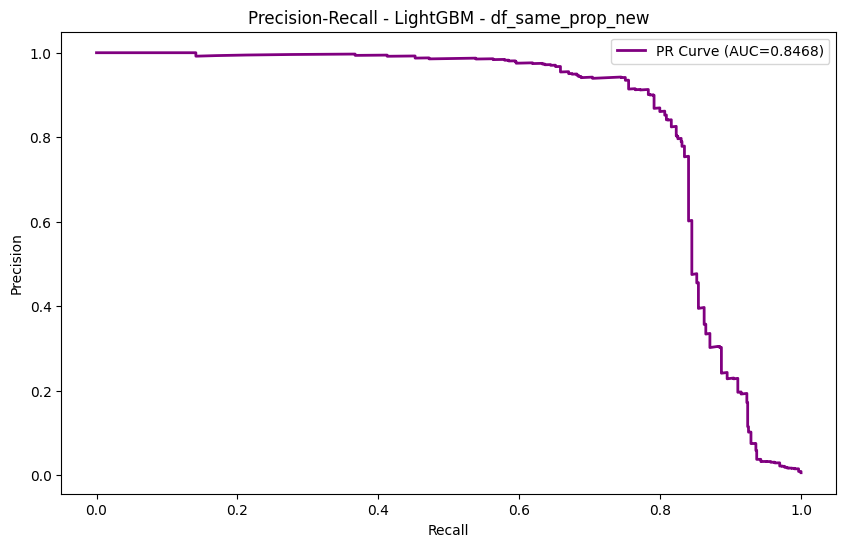

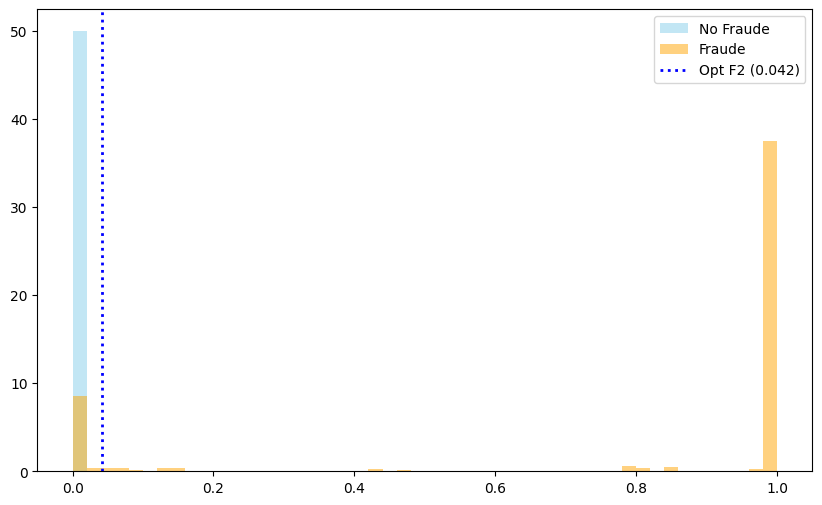

{'dataset': 'df_same_prop_new',
 'model': 'LightGBM_AllVars',
 'roc_auc': np.float64(0.9808591687023369),
 'auc_pr': np.float64(0.846760839986213),
 'f2_fraude_05': np.float64(0.8049832295160517),
 'best_thresh_f2': np.float64(0.04225222569851331),
 'f2_fraude_opt': np.float64(0.8234196407744343),
 'recall_at_f2_opt': np.float64(0.8228438228438228),
 'fraudes_totales': 858}

In [ ]:
eval_desbalanceado_lgbm_all_vars(df_same_prop_new, "df_same_prop_new")

## Más modelos con el dataset seleccionado

#### Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
)

def eval_desbalanceado_rf_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evalúa usando RANDOM FOREST con métricas para desbalance extremo.
    CORREGIDO: Maneja correctamente el One-Hot Encoding sin perder la fecha de referencia.
    """
    print(f"\n{'='*60}")
    print(f"Análisis detallado (RF - Todas las variables): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Preparación de Fechas
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No hay timestamp; se omite.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Selección de Variables (Limpieza previa al encoding)
    # ---------------------------------------------------------------------

    # Definimos columnas que NO deben entrar al get_dummies (Metadata y Target)
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    # Filtramos para borrar solo las que existan en tu DF actual
    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    # X_raw solo debe tener las variables predictivas (numéricas o categóricas)
    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    print(f"Variables antes de encoding: {X_raw.shape[1]}")

    # ---------------------------------------------------------------------
    # 2) Preprocesamiento: One-Hot Encoding
    # ---------------------------------------------------------------------
    # Aplicamos dummies solo a las variables predictivas
    X_processed = pd.get_dummies(X_raw, drop_first=True)

    print(f"Variables tras Encoding: {X_processed.shape[1]}")

    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Split Temporal (día 1 train, día 2 test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: El dataset necesita al menos 2 días distintos.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    # Separar Train y Test usando la fecha
    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    # Al crear X_train/X_test, eliminamos la columna de referencia temporal
    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Limpieza de Correlaciones
    # ---------------------------------------------------------------------
    print("\n=== Análisis de correlaciones (Todas las vars) ===")

    corr_matrix = X_train.corr().abs()
    threshold_corr = 0.75

    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

    print(f"Variables eliminadas por alta correlación (> {threshold_corr}): {len(to_drop_corr)}")

    X_train = X_train.drop(columns=to_drop_corr)
    X_test = X_test.drop(columns=to_drop_corr)

    print(f"Variables finales para el modelo: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Entrenar Random Forest
    # ---------------------------------------------------------------------
    model = RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',  # Vital para desbalance
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    print("\nEntrenando Random Forest...")
    model.fit(X_train, y_train)

    # Predicciones
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Métricas y Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Buscar el mejor F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f2_val))

    best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = 0.5, 0.0, 0.0, 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

    # Recalcular matriz para el óptimo
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Métricas base (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Threshold Óptimo RF (Max F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 7) Gráficas e Importancia
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'RF PR Curve (AUC={auc_pr:.4f})', color='green', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - Random Forest - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Feature Importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        # Asegurarnos de usar los nombres de columnas correctos (después de borrar correlacionadas)
        feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

        plt.figure(figsize=(10, 5))
        feat_imp.plot(kind='barh', color='teal')
        plt.title("Top 10 Variables Importantes (RF)")
        plt.gca().invert_yaxis()
        plt.show()

    return {
        'dataset': name,
        'model': 'RandomForest_AllVars',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }



Análisis detallado (RF - Todas las variables): df_same_prop_new
Variables antes de encoding: 30
Variables tras Encoding: 264
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones (Todas las vars) ===
Variables eliminadas por alta correlación (> 0.9): 0
Variables finales para el modelo: 264

Entrenando Random Forest...

AUC-PR:  0.8440
ROC-AUC: 0.9775

--- Threshold 0.5 ---
Recall: 0.6888 | F2: 0.7316

--- Threshold Óptimo RF (Max F2) ---
Threshold: 0.2145
F2 Score:  0.8379
Recall:    0.8252 (TP: 708)
Precision: 0.8928 (FP: 85)


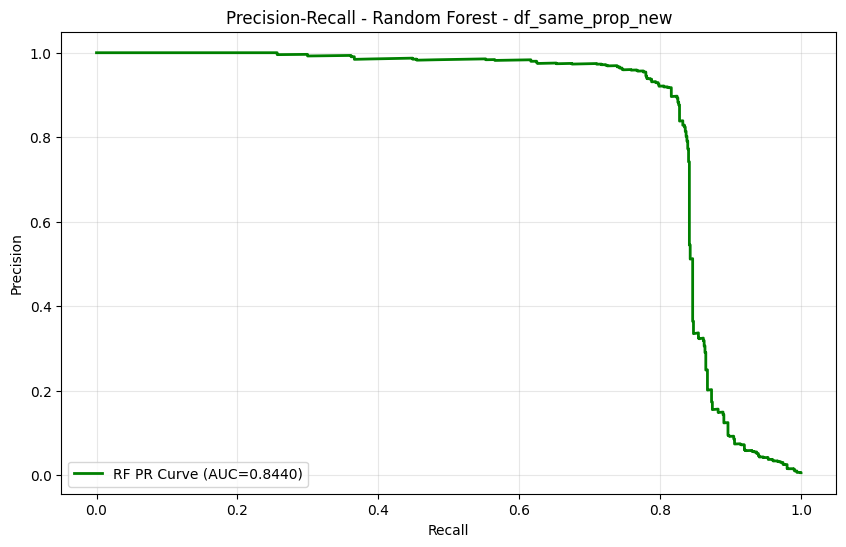

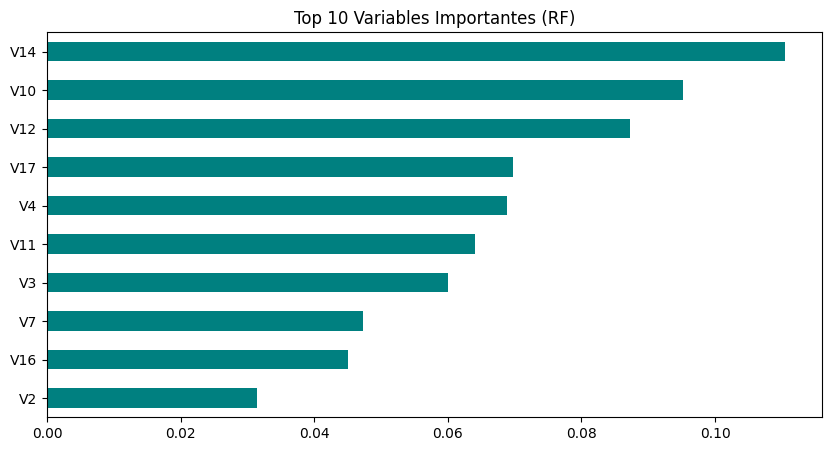

{'dataset': 'df_same_prop_new',
 'model': 'RandomForest_AllVars',
 'roc_auc': np.float64(0.9774563868814751),
 'auc_pr': np.float64(0.8440306835802142),
 'f2_fraude_05': np.float64(0.7316167368160434),
 'best_thresh_f2': np.float64(0.2145464808391192),
 'f2_fraude_opt': np.float64(0.8378698224852071),
 'recall_at_f2_opt': np.float64(0.8251748251748252),
 'fraudes_totales': 858}

In [ ]:
eval_desbalanceado_rf_all_vars(df_same_prop_new, "df_same_prop_new")

#### CatBoost

In [ ]:
def eval_desbalanceado_catboost_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evalúa usando CATBOOST con métricas para desbalance extremo.
    - NO usa One-Hot Encoding (aprovecha manejo nativo de CatBoost).
    - Detecta automáticamente columnas categóricas.
    - Split Temporal: Día 1 Train / Día 2 Test.
    """
    print(f"\n{'='*60}")
    print(f"Análisis detallado (CatBoost - Nativo): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Preparación de Fechas
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No hay timestamp; se omite.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Selección de Variables
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    # ---------------------------------------------------------------------
    # 2) Identificación de Categóricas (Sin One-Hot Encoding)
    # ---------------------------------------------------------------------
    # CatBoost necesita saber índices o nombres de las columnas categóricas.
    # Además, es recomendable convertir nulos en categóricas a un string explícito.

    cat_features_indices = []
    cat_features_names = []

    for col in X_raw.columns:
        # Si es objeto o categoria, lo tratamos como categorico
        if X_raw[col].dtype == 'object' or X_raw[col].dtype.name == 'category':
            cat_features_names.append(col)
            # Rellenar nulos categóricos para evitar errores
            X_raw[col] = X_raw[col].astype(str).fillna("MISSING")

    print(f"Total variables: {X_raw.shape[1]}")
    print(f"Variables Categóricas detectadas: {len(cat_features_names)}")

    # Añadimos referencia temporal para el split
    X_raw['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Split Temporal
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_raw['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: El dataset necesita al menos 2 días distintos.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_raw['date_split_ref'] == train_date
    mask_test = X_raw['date_split_ref'] == test_date

    X_train = X_raw[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_raw[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Limpieza de Correlaciones (Solo Numéricas)
    # ---------------------------------------------------------------------
    # Solo podemos calcular correlación estándar en variables numéricas.
    # Las categóricas las dejamos tal cual para que CatBoost decida.

    print("\n=== Análisis de correlaciones (Variables Numéricas) ===")

    # Seleccionar solo numéricas para la matriz de corr
    X_train_num = X_train.select_dtypes(include=[np.number])

    if not X_train_num.empty:
        corr_matrix = X_train_num.corr().abs()
        threshold_corr = 0.90

        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

        print(f"Variables numéricas eliminadas por alta correlación: {len(to_drop_corr)}")

        X_train = X_train.drop(columns=to_drop_corr)
        X_test = X_test.drop(columns=to_drop_corr)

        # Actualizar lista de categóricas por si acaso (aunque raro que una cat sea numérica correlacionada)
        cat_features_names = [c for c in cat_features_names if c in X_train.columns]
    else:
        print("No hay variables numéricas para analizar correlación.")

    print(f"Variables finales para el modelo: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Entrenar CatBoost
    # ---------------------------------------------------------------------
    # auto_class_weights='Balanced' es el equivalente a class_weight='balanced'
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0, # Silencioso
        allow_writing_files=False
    )

    print("\nEntrenando CatBoost (con soporte nativo de categorías)...")

    # Pasamos cat_features explícitamente
    model.fit(X_train, y_train, cat_features=cat_features_names)

    # Predicciones
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Métricas y Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Buscar el mejor F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f2_val))

    best_thresh_f2 = 0.5
    best_f2_score = 0.0
    best_rec_f2 = 0.0
    best_prec_f2 = 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

    # Matriz Óptima
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Métricas Base (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()

    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | Precision: {prec_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Threshold Óptimo CatBoost (Max F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 7) Gráficas e Importancia
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'CatBoost PR Curve (AUC={auc_pr:.4f})', color='darkorange', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - CatBoost - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Feature Importance
    # CatBoost tiene su propio método get_feature_importance()
    importances = model.get_feature_importance()
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    feat_imp.plot(kind='barh', color='brown')
    plt.title("Top 10 Variables Importantes (CatBoost)")
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'dataset': name,
        'model': 'CatBoost_AllVars',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }




Análisis detallado (CatBoost - Nativo): df_same_prop_new
Total variables: 30
Variables Categóricas detectadas: 1
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones (Variables Numéricas) ===
Variables numéricas eliminadas por alta correlación: 0
Variables finales para el modelo: 30

Entrenando CatBoost (con soporte nativo de categorías)...

AUC-PR:  0.8323
ROC-AUC: 0.9685

--- Threshold 0.5 ---
Recall: 0.7960 | Precision: 0.8975 | F2: 0.8145

--- Threshold Óptimo CatBoost (Max F2) ---
Threshold: 0.7392
F2 Score:  0.8182
Recall:    0.7960 (TP: 683)
Precision: 0.9205 (FP: 59)


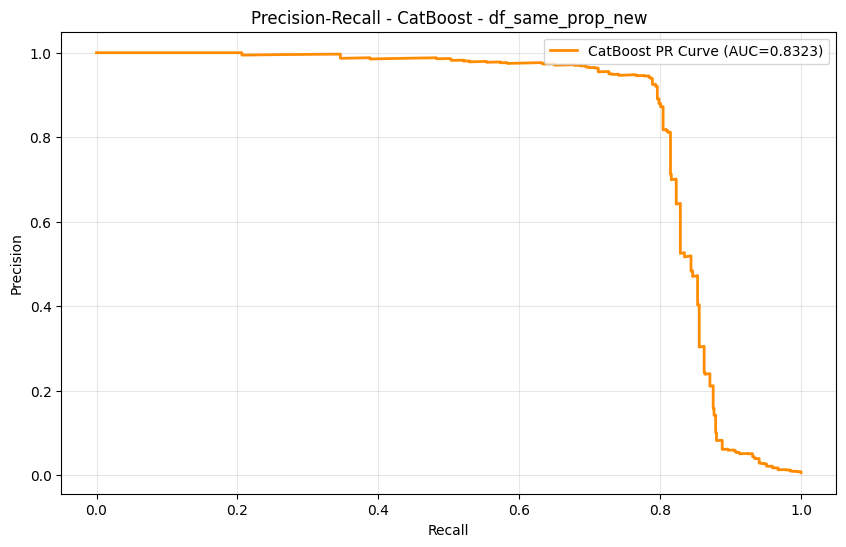

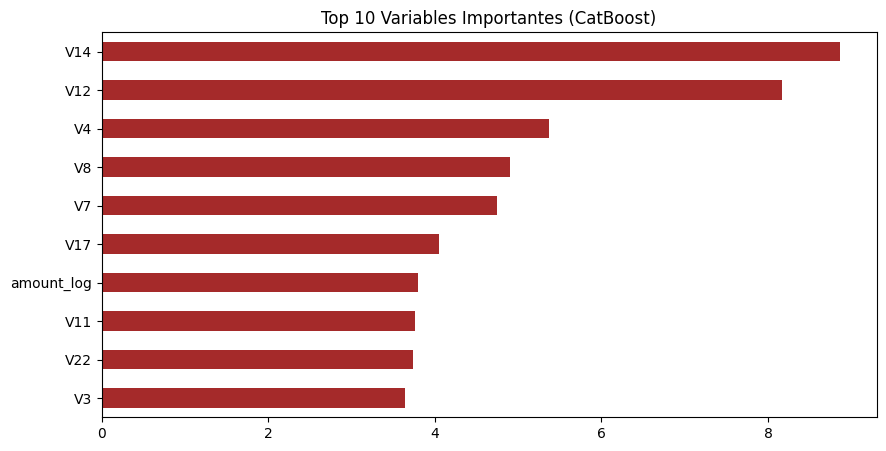

{'dataset': 'df_same_prop_new',
 'model': 'CatBoost_AllVars',
 'roc_auc': np.float64(0.9684959422344078),
 'auc_pr': np.float64(0.8323379644572639),
 'f2_fraude_05': np.float64(0.8144526591938946),
 'best_thresh_f2': np.float64(0.7391714252789015),
 'f2_fraude_opt': np.float64(0.8181600383325347),
 'recall_at_f2_opt': np.float64(0.796037296037296),
 'fraudes_totales': 858}

In [ ]:
eval_desbalanceado_catboost_all_vars(df_same_prop_new, "df_same_prop_new")

#### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def eval_desbalanceado_lr_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evalúa usando LOGISTIC REGRESSION con métricas para desbalance extremo.
    - Requiere One-Hot Encoding.
    - Requiere StandardScaler (Normalización).
    - Usa class_weight='balanced'.
    """
    print(f"\n{'='*60}")
    print(f"Análisis detallado (Logistic Regression): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Preparación de Fechas
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No hay timestamp; se omite.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Selección de Variables
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    print(f"Variables antes de encoding: {X_raw.shape[1]}")

    # ---------------------------------------------------------------------
    # 2) Encoding (Obligatorio para LR)
    # ---------------------------------------------------------------------
    X_processed = pd.get_dummies(X_raw, drop_first=True)
    print(f"Variables tras Encoding: {X_processed.shape[1]}")

    # Añadimos referencia temporal POST-ENCODING para no perderla
    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Split Temporal
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: El dataset necesita al menos 2 días distintos.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Limpieza de Correlaciones
    # ---------------------------------------------------------------------
    # Es muy importante en Regresión Logística quitar multicolinealidad
    print("\n=== Análisis de correlaciones ===")

    corr_matrix = X_train.corr().abs()
    threshold_corr = 0.90

    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

    print(f"Variables eliminadas por alta correlación: {len(to_drop_corr)}")

    X_train = X_train.drop(columns=to_drop_corr)
    X_test = X_test.drop(columns=to_drop_corr)

    # ---------------------------------------------------------------------
    # 5) ESCALADO (Vital para LR)
    # ---------------------------------------------------------------------
    print("\nAplicando StandardScaler (necesario para LR)...")
    scaler = StandardScaler()

    # Ajustamos scaler solo en train, transformamos ambos
    # Reconstruimos DataFrame para mantener nombres de columnas para el gráfico final
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    print(f"Variables finales para el modelo: {X_train_scaled.shape[1]}")

    # ---------------------------------------------------------------------
    # 6) Entrenar Logistic Regression
    # ---------------------------------------------------------------------
    model = LogisticRegression(
        penalty='l2',            # Regularización Ridge por defecto
        C=1.0,                   # Inverso de fuerza de regularización
        class_weight='balanced', # Pesos automáticos para desbalance
        solver='lbfgs',
        max_iter=2000,           # Aumentamos iteraciones para asegurar convergencia
        random_state=42,
        n_jobs=-1
    )

    print("\nEntrenando Logistic Regression...")
    model.fit(X_train_scaled, y_train)

    # Predicciones
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Métricas y Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Buscar el mejor F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f2_val))

    best_thresh_f2 = 0.5
    best_f2_score = 0.0
    best_rec_f2 = 0.0
    best_prec_f2 = 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

    # Matriz Óptima
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Métricas Base (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | Precision: {prec_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Threshold Óptimo LR (Max F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 8) Gráficas y Coeficientes
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'LR PR Curve (AUC={auc_pr:.4f})', color='navy', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - Logistic Regression - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Interpretación de Coeficientes (Top 10 absolutos)
    # En LR, un coeficiente alto (positivo o negativo) indica mayor impacto
    coeffs = pd.Series(model.coef_[0], index=X_train.columns)

    # Ordenamos por magnitud absoluta
    top_coeffs = coeffs.abs().sort_values(ascending=False).head(10)
    # Recuperamos el signo original para el color
    top_coeffs_original = coeffs.loc[top_coeffs.index]

    colors = ['red' if x < 0 else 'blue' for x in top_coeffs_original]

    plt.figure(figsize=(10, 5))
    top_coeffs_original.plot(kind='barh', color=colors)
    plt.title("Top 10 Coeficientes con mayor impacto (Azul: Positivo, Rojo: Negativo)")
    plt.xlabel("Valor del Coeficiente (datos escalados)")
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'dataset': name,
        'model': 'LogisticRegression_AllVars',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Análisis detallado (Logistic Regression): df_same_prop_new
Variables antes de encoding: 30
Variables tras Encoding: 264
Train date: 2023-01-01 | Test date: 2023-01-02

=== Análisis de correlaciones ===
Variables eliminadas por alta correlación: 0

Aplicando StandardScaler (necesario para LR)...
Variables finales para el modelo: 264

Entrenando Logistic Regression...

AUC-PR:  0.7650
ROC-AUC: 0.9260

--- Threshold 0.5 ---
Recall: 0.8473 | Precision: 0.0983 | F2: 0.3356

--- Threshold Óptimo LR (Max F2) ---
Threshold: 0.9981
F2 Score:  0.7636
Recall:    0.7681 (TP: 659)
Precision: 0.7463 (FP: 224)


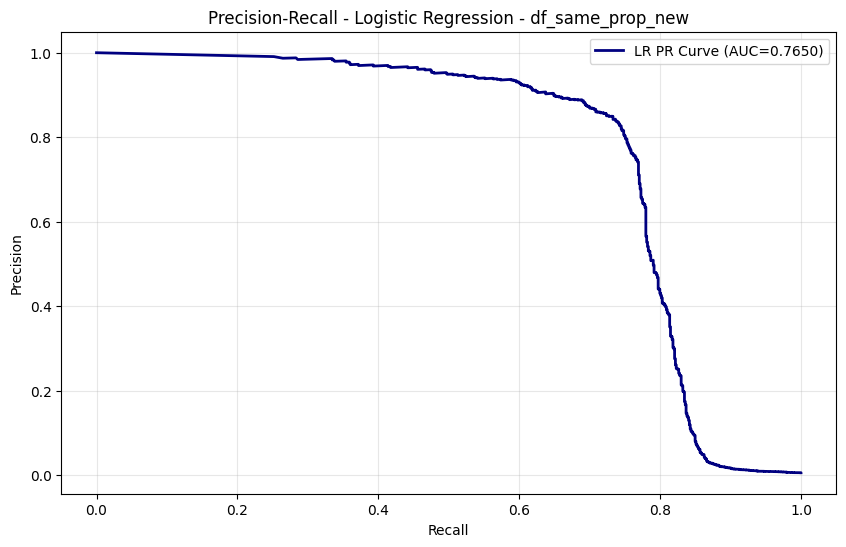

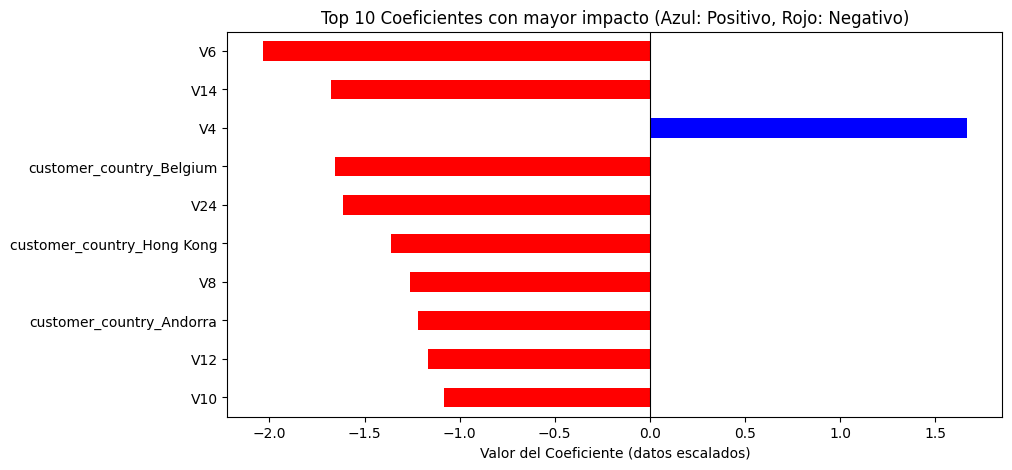

{'dataset': 'df_same_prop_new',
 'model': 'LogisticRegression_AllVars',
 'roc_auc': np.float64(0.9259563886919979),
 'auc_pr': np.float64(0.7649955860439307),
 'f2_fraude_05': np.float64(0.33564173591874424),
 'best_thresh_f2': np.float64(0.9980503892095534),
 'f2_fraude_opt': np.float64(0.7636152954808807),
 'recall_at_f2_opt': np.float64(0.7680652680652681),
 'fraudes_totales': 858}

In [ ]:
eval_desbalanceado_lr_all_vars(df_same_prop_new, "df_same_prop_new")

### Hyperparameter tunning with best model and best df

Best model is random forest



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
    make_scorer,
    fbeta_score
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def tune_and_eval_rf(df_in: pd.DataFrame, name: str, n_iter=3) -> dict:
    """
    Versión RÁPIDA para Tuning.
    - n_iter=3 por defecto.
    - cv=3 (StratifiedKFold).
    - Total fits = 3 * 3 = 9 fits ( < 10 ).
    """
    print(f"\n{'='*80}")
    print(f"Hyperparameter Tuning RÁPIDO (RF) - Max 9 fits: {name}")
    print(f"{'='*80}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Preparación de Fechas
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No hay timestamp; se omite.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Selección de Variables y Encoding
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]
    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    # One-Hot Encoding
    X_processed = pd.get_dummies(X_raw, drop_first=True)

    # Re-inyectamos la fecha para el split
    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 2) Split Temporal
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: Se requieren al menos 2 días para Train/Test.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 3) Limpieza de Correlaciones (Solo en Train)
    # ---------------------------------------------------------------------
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

    X_train = X_train.drop(columns=to_drop)
    X_test = X_test.drop(columns=to_drop)

    print(f"Vars finales: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 4) Definición del TUNING (RandomizedSearchCV)
    # ---------------------------------------------------------------------
    f2_scorer = make_scorer(fbeta_score, beta=2)

    # Grilla reducida para prueba rápida
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 10],
        'min_samples_leaf': [1, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': ['balanced', 'balanced_subsample']
    }

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    # cv=3 * n_iter=3 = 9 fits totales
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=n_iter,           # <--- AQUI limitamos a 3 por defecto
        scoring=f2_scorer,
        cv=StratifiedKFold(3),   # 3 folds
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    print(f"\nIniciando búsqueda RÁPIDA ({n_iter} iters * 3 folds = {n_iter*3} fits)...")

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    print(f"\nMejores parámetros encontrados: \n{best_params}")
    print(f"Mejor F2 Score en CV (Train): {random_search.best_score_:.4f}")

    # ---------------------------------------------------------------------
    # 5) Evaluación
    # ---------------------------------------------------------------------
    y_proba = best_model.predict_proba(X_test)[:, 1]

    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, f2_val))

    best_row = max(scores_list, key=lambda x: x[1]) if scores_list else (0.5, 0.0)
    best_thresh_f2, best_f2_score = best_row

    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn, fp, fn, tp = cm_opt.ravel()

    recall_opt = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec_opt = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"\n--- Resultados en TEST (Mejor Modelo) ---")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"AUC-PR:  {auc_pr:.4f}")
    print(f"Threshold Óptimo: {best_thresh_f2:.4f}")
    print(f"F2 Score (Test):  {best_f2_score:.4f}")
    print(f"Recall (Test):    {recall_opt:.4f}")
    print(f"Precision (Test): {prec_opt:.4f}")

    # ---------------------------------------------------------------------
    # 6) Gráficas
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'Best RF (AUC={auc_pr:.4f})', color='purple', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve - Tuned Random Forest - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    feat_imp.plot(kind='barh', color='indigo')
    plt.title("Top 10 Variables Importantes (Tuned RF)")
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'model': best_model,
        'best_params': best_params,
        'roc_auc': roc_auc,
        'f2_score': best_f2_score,
        'best_thresh': best_thresh_f2
    }



Hyperparameter Tuning RÁPIDO (RF) - Max 9 fits: df_same_prop_new
Train date: 2023-01-01 | Test date: 2023-01-02
Vars finales: 264

Iniciando búsqueda RÁPIDA (3 iters * 3 folds = 9 fits)...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Mejores parámetros encontrados: 
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced_subsample'}
Mejor F2 Score en CV (Train): 0.9589

--- Resultados en TEST (Mejor Modelo) ---
ROC-AUC: 0.9835
AUC-PR:  0.8481
Threshold Óptimo: 0.3434
F2 Score (Test):  0.8329
Recall (Test):    0.8147
Precision (Test): 0.9149


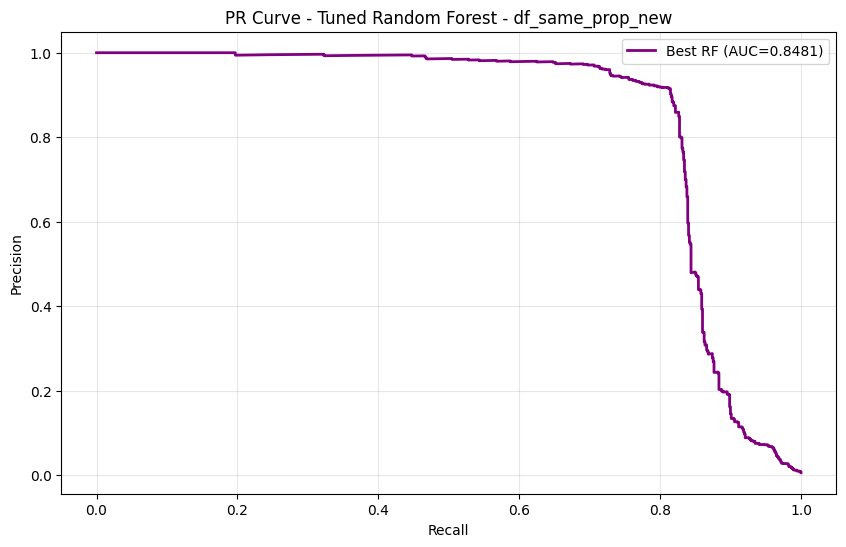

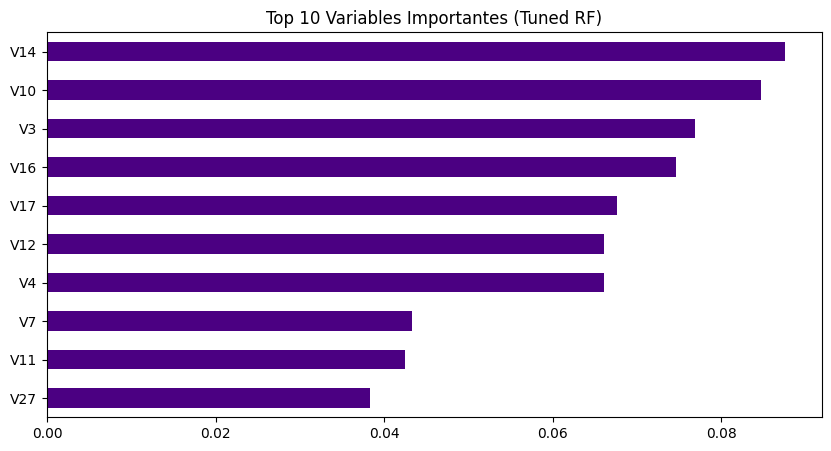

In [ ]:
results = tune_and_eval_rf(df_same_prop_new, "df_same_prop_new", n_iter=3)